# SEG Embedding & Representation Analysis — BACE

**Zentrale Frage:** Gilt der Vorteil einer gefrorenen, zufällig initialisierten Text-Projektion auch für eine *härtere*, weniger topologisch inferierte Task?

**BACE vs ESOL:**
- BACE = binäre Klassifikation (BACE-1 Inhibitor-Aktivität), weniger durch einfache Topologie erklärbar
- ESOL = Regression (Löslichkeit), stark topologisch (≈ f(Polarität, Größe))

## Analysen

1. **Multi-Seed Training** — 4 Configs × 6 Seeds: frozen/unfrozen × xavier/kaiming
2. **Effective Rank** — SVD-Analyse der Graph-, TextProj- und Fused-Repräsentationen + Projektionsgewichte
3. **JL Distance Preservation** — Distanzerhaltung der Text-Projektion
4. **Embedding-Stabilität** — CKA über Seeds (Graph, TextProj, Fused)
5. **Tanimoto & |Δy| Correlation** — Strukturelle + task-relevante Ähnlichkeit
6. **Learning Curves** — Overfitting-Verhalten frozen vs unfrozen

In [13]:
# === Setup ===
import sys
import random
from pathlib import Path
workspace_root = Path.cwd().parent
if str(workspace_root) not in sys.path:
    sys.path.insert(0, str(workspace_root))

import numpy as np
import pandas as pd
import torch
import deepchem as dc
import matplotlib.pyplot as plt
from typing import Dict, List, Any
from scipy import stats
from scipy.spatial.distance import pdist
from scipy.stats import spearmanr
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score

from utils.embedding_cache import EfficientEmbeddingCache
from utils.molecular_graph import smiles_to_graph
from utils.batched_mol_graph import batch_graphs
from models import SEGPredictor, SEGPredictorConfig

print(f"Workspace: {workspace_root}")
print(f"PyTorch: {torch.__version__}, CUDA: {torch.cuda.is_available()}")

Workspace: c:\Users\robsc\Home\Dev\molfusion2
PyTorch: 2.6.0+cu124, CUDA: True


In [14]:
# === Load BACE Data ===
tasks, datasets, _ = dc.molnet.load_bace_classification(featurizer='ECFP', splitter='scaffold')
train_dc, valid_dc, test_dc = datasets

TRAIN_SMILES = list(train_dc.ids)
TRAIN_Y = train_dc.y.reshape(-1).astype(np.float32)
VALID_SMILES = list(valid_dc.ids)
VALID_Y = valid_dc.y.reshape(-1).astype(np.float32)
TEST_SMILES = list(test_dc.ids)
TEST_Y = test_dc.y.reshape(-1).astype(np.float32)

# Text embeddings
COT_EMB_DIR = workspace_root / "cache" / "cot_embeddings"
npz_path = COT_EMB_DIR / "binding_fast_text_embeddings_compact.npz"
cache = EfficientEmbeddingCache.load(npz_path)

all_smiles = TRAIN_SMILES + VALID_SMILES + TEST_SMILES
all_emb = torch.from_numpy(cache.get_batch(all_smiles))
n_train, n_valid = len(TRAIN_SMILES), len(VALID_SMILES)
TRAIN_TEXT_EMB = all_emb[:n_train]
VALID_TEXT_EMB = all_emb[n_train:n_train + n_valid]
TEST_TEXT_EMB = all_emb[n_train + n_valid:]

print(f"Train: {n_train} ({TRAIN_Y.mean()*100:.1f}% active) | Valid: {n_valid} | Test: {len(TEST_SMILES)}")
print(f"Text embeddings: {TRAIN_TEXT_EMB.shape[1]}D")

Loading embeddings from binding_fast_text_embeddings_compact.npz...
  Loaded 1513 entries, dim=3072
  Memory mode: mapped
Train: 1210 (42.6% active) | Valid: 151 | Test: 152
Text embeddings: 3072D


In [15]:
# === Helper Functions ===

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def classification_metrics(y_true, y_pred_proba, threshold=0.5) -> Dict[str, float]:
    y_true = np.asarray(y_true).reshape(-1)
    y_pred_proba = np.clip(np.asarray(y_pred_proba).reshape(-1), 0, 1)
    mask = np.isfinite(y_pred_proba)
    y_true, y_pred_proba = y_true[mask], y_pred_proba[mask]
    y_pred = (y_pred_proba >= threshold).astype(int)
    return {
        "roc_auc": float(roc_auc_score(y_true, y_pred_proba)),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
    }


def effective_rank(S: np.ndarray) -> float:
    """Entropy-based effective rank from singular values."""
    S_prob = (S**2) / np.sum(S**2)
    S_prob = S_prob[S_prob > 1e-10]
    return float(np.exp(-np.sum(S_prob * np.log(S_prob))))


def extract_graph_embeddings(model: SEGPredictor, smiles_list: List[str], batch_size: int = 32) -> np.ndarray:
    model._encoder.eval()
    model._pooling.eval()
    embeddings = []
    valid_graphs = []
    for smi in smiles_list:
        try:
            g = smiles_to_graph(smi, add_hydrogens=model.config.add_hydrogens)
            valid_graphs.append(g)
        except Exception:
            continue
    with torch.no_grad():
        for start in range(0, len(valid_graphs), batch_size):
            chunk = valid_graphs[start:start + batch_size]
            bg = batch_graphs(chunk)
            x, edge_index, edge_weight, batch = model._to_tensors(bg)
            node_emb = model._encoder(x, edge_index, edge_weight, batch)
            graph_emb = model._pooling(node_emb, batch)
            embeddings.append(graph_emb.cpu().numpy())
    return np.vstack(embeddings)


def extract_projected_text_embeddings(model: SEGPredictor, text_emb: torch.Tensor) -> np.ndarray:
    if model._text_proj is not None:
        model._text_proj.eval()
        with torch.no_grad():
            projected = model._text_proj(text_emb.to(model.device))
        return projected.cpu().numpy()
    return text_emb.numpy()


def extract_fused_embeddings(model: SEGPredictor, smiles_list: List[str],
                              text_emb: torch.Tensor, batch_size: int = 32) -> np.ndarray:
    model._encoder.eval()
    model._pooling.eval()
    model._fusion.eval()
    if model._text_proj is not None:
        model._text_proj.eval()
    embeddings = []
    valid_graphs = []
    valid_text = []
    for i, smi in enumerate(smiles_list):
        try:
            g = smiles_to_graph(smi, add_hydrogens=model.config.add_hydrogens)
            valid_graphs.append(g)
            valid_text.append(text_emb[i])
        except Exception:
            continue
    valid_text_t = torch.stack(valid_text)
    with torch.no_grad():
        for start in range(0, len(valid_graphs), batch_size):
            chunk_graphs = valid_graphs[start:start + batch_size]
            chunk_text = valid_text_t[start:start + batch_size].to(model.device)
            bg = batch_graphs(chunk_graphs)
            x, edge_index, edge_weight, batch = model._to_tensors(bg)
            node_emb = model._encoder(x, edge_index, edge_weight, batch)
            graph_emb = model._pooling(node_emb, batch)
            if model._text_proj is not None:
                chunk_text = model._text_proj(chunk_text)
            fused = model._fusion(graph_emb, chunk_text)
            embeddings.append(fused.cpu().numpy())
    return np.vstack(embeddings)


def train_and_collect(config: Dict[str, Any], seed: int, verbose: bool = False) -> Dict[str, Any]:
    """Train a model and collect all embeddings + metrics."""
    set_seed(seed)
    seg_config = SEGPredictorConfig(
        task="classification",
        hidden_channels=config.get("hidden_channels", 64),
        K=config.get("K", 3),
        num_layers=config.get("num_layers", 2),
        dropout=config.get("dropout", 0.3),
        pool=config.get("pool", "sum"),
        set2set_processing_steps=config.get("set2set_processing_steps", 6),
        text_embedding_dim=3072,
        text_projection_dim=config.get("text_projection_dim", 64),
        text_proj_init=config.get("text_proj_init", "xavier"),
        text_proj_init_gain=config.get("text_proj_init_gain", 0.1),
        freeze_text_proj=config.get("freeze_text_proj", True),
        fusion=config.get("fusion", "cross_mha"),
        fusion_dim=config.get("fusion_dim", 64),
        fusion_n_heads=config.get("fusion_n_heads", 8),
        fusion_dropout=config.get("fusion_dropout", 0.3),
        head_type=config.get("head_type", "mlp"),
        head_hidden_dim=config.get("head_hidden_dim", 32),
        head_dropout=config.get("head_dropout", 0.5),
    )
    seg = SEGPredictor(config=seg_config)
    history = seg.fit(
        smiles_list=TRAIN_SMILES,
        labels=TRAIN_Y.tolist(),
        val_smiles=VALID_SMILES,
        val_labels=VALID_Y.tolist(),
        text_embeddings=TRAIN_TEXT_EMB,
        val_text_embeddings=VALID_TEXT_EMB,
        num_epochs=config.get("num_epochs", 200),
        batch_size=config.get("batch_size", 32),
        learning_rate=config.get("learning_rate", 5e-4),
        weight_decay=config.get("weight_decay", 1e-1),
        patience=config.get("patience", 20),
        scheduler=config.get("scheduler", "cosine"),
        scheduler_patience=config.get("scheduler_patience", 5),
        scheduler_factor=config.get("scheduler_factor", 0.5),
        min_lr=config.get("min_lr", 1e-6),
        grad_clip=config.get("grad_clip", None),
        seed=seed,
        verbose=verbose,
    )
    # Test metrics
    preds = seg.predict_batch(TEST_SMILES, text_embeddings=TEST_TEXT_EMB)
    metrics = classification_metrics(TEST_Y, preds)
    # Extract embeddings on test set
    graph_emb = extract_graph_embeddings(seg, TEST_SMILES)
    text_proj_emb = extract_projected_text_embeddings(seg, TEST_TEXT_EMB)
    fused_emb = extract_fused_embeddings(seg, TEST_SMILES, TEST_TEXT_EMB)
    # SVD analysis
    _, S_graph, _ = np.linalg.svd(graph_emb, full_matrices=False)
    _, S_text_proj, _ = np.linalg.svd(text_proj_emb, full_matrices=False)
    _, S_fused, _ = np.linalg.svd(fused_emb, full_matrices=False)
    # Text projection weight SVD
    text_proj_weight_S = None
    if seg._text_proj is not None:
        W = seg._text_proj[0].weight.detach().cpu().numpy()
        _, text_proj_weight_S, _ = np.linalg.svd(W, full_matrices=False)
    return {
        "seed": seed, "metrics": metrics, "history": history, "model": seg,
        "graph_emb": graph_emb, "text_proj_emb": text_proj_emb, "fused_emb": fused_emb,
        "S_graph": S_graph, "S_text_proj": S_text_proj, "S_fused": S_fused,
        "text_proj_weight_S": text_proj_weight_S,
    }


print("\u2713 Helper functions loaded")

✓ Helper functions loaded


---
## 0. Baseline Comparison

| Modell | Beschreibung |
|--------|-------------|
| RF (ECFP+Desc) | Random Forest auf ECFP-Counts + 217 RDKit-Deskriptoren |
| ChebNet only | Graph-only Baseline (gleiche Architektur wie SEG-Encoder) |
| Text MLP | 2-Layer MLP auf 3072D LLM-Embeddings (BCE) |
| SEG frozen / learned | Vollständiges Modell mit/ohne freeze_text_proj |

Computing molecular features...
Features: ECFP=2048 + Desc=217 = 2265
  RF seed=42: AUC=0.8232
  RF seed=113: AUC=0.8252
  RF seed=456: AUC=0.8201
  RF seed=789: AUC=0.8212
  RF Mean: 0.8224±0.0019

  ChebNet seed=42: AUC=0.6667
  ChebNet seed=113: AUC=0.2730
  ChebNet seed=456: AUC=0.2784
  ChebNet seed=789: AUC=0.3873
  ChebNet Mean: 0.4014±0.1598

  TextMLP seed=42: AUC=0.5677
  TextMLP seed=113: AUC=0.6133
  TextMLP seed=456: AUC=0.3793
  TextMLP seed=789: AUC=0.4374
  TextMLP Mean: 0.4994±0.0948

  (Reusing SEG results from main experiments)

BASELINE COMPARISON — BACE Scaffold Split

Model                                 AUC-ROC    n
----------------------------------------------------
  Random Forest (ECFP+Desc)  0.8224±0.0019     4
  ChebNet only (Graph)       0.4014±0.1598     4
  Text MLP only (LLM)        0.4994±0.0948     4
  SEG (frozen text_proj)     0.8035±0.0681     4
  SEG (learned text_proj)    0.8464±0.0215     4


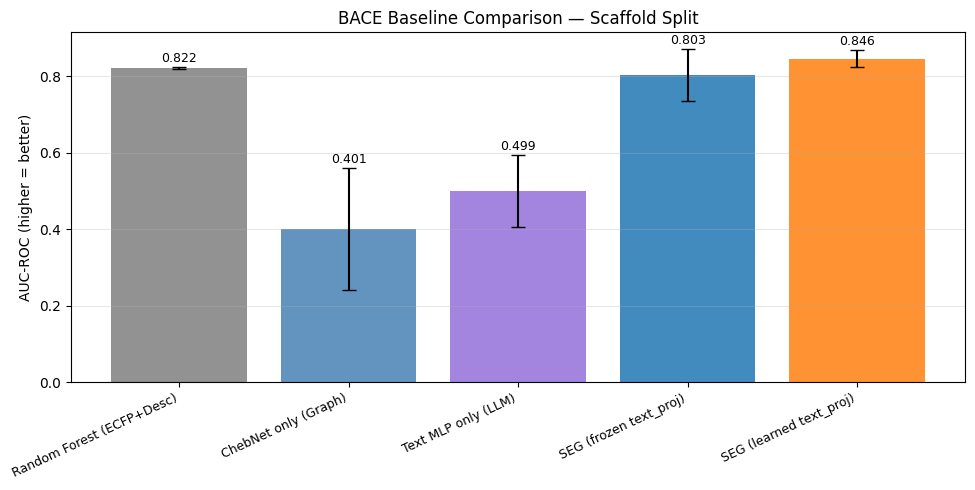

In [16]:
# === Baseline Comparison: RF, ChebNet, Text-MLP, SEG ===
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
from models.cheb_predictor import ChebPredictor, ChebPredictorConfig

BASELINE_SEEDS = [42, 113, 456, 789]
morgan_gen = GetMorganGenerator(radius=2, fpSize=2048)

def smiles_to_features(smiles_list):
    """ECFP count fingerprints + RDKit 2D descriptors."""
    desc_names = [name for name, _ in Descriptors.descList]
    fps, descs = [], []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            fp = morgan_gen.GetCountFingerprint(mol)
            fps.append(np.array([fp[i] for i in range(2048)], dtype=np.float32))
            all_d = Descriptors.CalcMolDescriptors(mol)
            desc_vals = []
            for name in desc_names:
                try:
                    val = float(all_d.get(name, 0.0))
                    desc_vals.append(val if np.isfinite(val) else 0.0)
                except (TypeError, ValueError):
                    desc_vals.append(0.0)
            descs.append(desc_vals)
        else:
            fps.append(np.zeros(2048, dtype=np.float32))
            descs.append([0.0] * len(desc_names))
    desc_arr = np.array(descs, dtype=np.float32)
    desc_arr = np.nan_to_num(desc_arr, nan=0.0, posinf=0.0, neginf=0.0)
    return np.array(fps), desc_arr

print("Computing molecular features...")
train_fps, train_descs = smiles_to_features(TRAIN_SMILES)
valid_fps, valid_descs = smiles_to_features(VALID_SMILES)
test_fps_arr, test_descs = smiles_to_features(TEST_SMILES)

desc_scaler = StandardScaler()
train_descs_s = desc_scaler.fit_transform(train_descs)
valid_descs_s = desc_scaler.transform(valid_descs)
test_descs_s = desc_scaler.transform(test_descs)
train_X = np.hstack([train_fps, train_descs_s])
valid_X = np.hstack([valid_fps, valid_descs_s])
test_X = np.hstack([test_fps_arr, test_descs_s])
print(f"Features: ECFP={train_fps.shape[1]} + Desc={train_descs.shape[1]} = {train_X.shape[1]}")

# --- 1. Random Forest (Classification) ---
rf_results = []
for seed in BASELINE_SEEDS:
    rf = RandomForestClassifier(n_estimators=1000, max_features="sqrt",
                                min_samples_leaf=2, random_state=seed, n_jobs=-1)
    rf.fit(train_X, TRAIN_Y)
    preds = rf.predict_proba(test_X)[:, 1]
    auc = float(roc_auc_score(TEST_Y, preds))
    rf_results.append(auc)
    print(f"  RF seed={seed}: AUC={auc:.4f}")
print(f"  RF Mean: {np.mean(rf_results):.4f}±{np.std(rf_results):.4f}\n")

# --- 2. ChebNet only (no text) ---
cheb_results = []
for seed in BASELINE_SEEDS:
    set_seed(seed)
    cheb = ChebPredictor(config=ChebPredictorConfig(
        task="classification", hidden_channels=64, K=3, num_layers=2,
        pool="sum", dropout=0.3, head_hidden_dim=32, head_dropout=0.5,
    ))
    cheb.fit(TRAIN_SMILES, TRAIN_Y.tolist(),
             val_smiles=VALID_SMILES, val_labels=VALID_Y.tolist(),
             num_epochs=200, batch_size=32, learning_rate=5e-4,
             weight_decay=1e-1, patience=20, seed=seed, verbose=False)
    preds = cheb.predict_batch(TEST_SMILES)
    m = classification_metrics(TEST_Y, preds)
    cheb_results.append(m["roc_auc"])
    print(f"  ChebNet seed={seed}: AUC={m['roc_auc']:.4f}")
print(f"  ChebNet Mean: {np.mean(cheb_results):.4f}±{np.std(cheb_results):.4f}\n")

# --- 3. Text MLP only (BCE) ---
class TextMLP(torch.nn.Module):
    def __init__(self, input_dim=3072, hidden_dim=128, dropout=0.5):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(input_dim, hidden_dim), torch.nn.ReLU(), torch.nn.Dropout(dropout),
            torch.nn.Linear(hidden_dim, hidden_dim // 2), torch.nn.ReLU(), torch.nn.Dropout(dropout),
            torch.nn.Linear(hidden_dim // 2, 1),
        )
    def forward(self, x): return self.net(x).squeeze(-1)

text_results = []
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
for seed in BASELINE_SEEDS:
    set_seed(seed)
    mlp = TextMLP().to(device)
    opt = torch.optim.Adam(mlp.parameters(), lr=5e-4, weight_decay=1e-1)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5, factor=0.5)
    tx, ty = TRAIN_TEXT_EMB.to(device), torch.tensor(TRAIN_Y, device=device)
    vx, vy = VALID_TEXT_EMB.to(device), torch.tensor(VALID_Y, device=device)
    best_val, pat_ctr, best_st = float("inf"), 0, None
    for ep in range(200):
        mlp.train(); perm = torch.randperm(len(tx))
        for s in range(0, len(tx), 32):
            idx = perm[s:s+32]
            loss = torch.nn.functional.binary_cross_entropy_with_logits(mlp(tx[idx]), ty[idx])
            opt.zero_grad(); loss.backward(); opt.step()
        mlp.eval()
        with torch.no_grad():
            vl = float(torch.nn.functional.binary_cross_entropy_with_logits(mlp(vx), vy))
        sched.step(vl)
        if vl < best_val:
            best_val, best_st, pat_ctr = vl, {k: v.clone() for k, v in mlp.state_dict().items()}, 0
        else:
            pat_ctr += 1
            if pat_ctr >= 30: break
    mlp.load_state_dict(best_st); mlp.eval()
    with torch.no_grad():
        tp = torch.sigmoid(mlp(TEST_TEXT_EMB.to(device))).cpu().numpy()
    m = classification_metrics(TEST_Y, tp)
    text_results.append(m["roc_auc"])
    print(f"  TextMLP seed={seed}: AUC={m['roc_auc']:.4f}")
print(f"  TextMLP Mean: {np.mean(text_results):.4f}±{np.std(text_results):.4f}\n")

# --- 4. SEG frozen & learned ---
seg_frozen_results, seg_learned_results = [], []
_has = "ALL_RESULTS" in dir() and isinstance(ALL_RESULTS, dict) and \
    "xavier_frozen" in ALL_RESULTS and len(ALL_RESULTS.get("xavier_frozen", {})) >= 4
if _has:
    for seed in list(ALL_RESULTS["xavier_frozen"].keys())[:4]:
        seg_frozen_results.append(ALL_RESULTS["xavier_frozen"][seed]["metrics"]["roc_auc"])
        seg_learned_results.append(ALL_RESULTS["xavier_learned"][seed]["metrics"]["roc_auc"])
    print("  (Reusing SEG results from main experiments)")
else:
    _seg_base = {
        "hidden_channels": 128, "K": 3, "num_layers": 3, "pool": "sum",
        "fusion": "cross_mha", "fusion_dim": 32, "fusion_n_heads": 8,
        "text_projection_dim": 32,
        "dropout": 0.3, "fusion_dropout": 0.3, "head_dropout": 0.5,
        "weight_decay": 1e-1, "head_type": "mlp", "head_hidden_dim": 32,
        "learning_rate": 5e-4, "batch_size": 128, "num_epochs": 200, "patience": 20,
        "scheduler": "cosine", "scheduler_patience": 5, "scheduler_factor": 0.5,
        "min_lr": 1e-6, "grad_clip": None,
    }
    for seed in BASELINE_SEEDS:
        for cn, fr in [("frozen", True), ("learned", False)]:
            r = train_and_collect({**_seg_base, "text_proj_init": "xavier",
                "text_proj_init_gain": 0.1, "freeze_text_proj": fr}, seed, verbose=False)
            (seg_frozen_results if fr else seg_learned_results).append(r["metrics"]["roc_auc"])
            print(f"  SEG {cn} seed={seed}: AUC={r['metrics']['roc_auc']:.4f}")

# === Summary ===
print("\n" + "=" * 65)
print("BASELINE COMPARISON — BACE Scaffold Split")
print("=" * 65)
baselines = {
    "Random Forest (ECFP+Desc)": rf_results,
    "ChebNet only (Graph)": cheb_results,
    "Text MLP only (LLM)": text_results,
    "SEG (frozen text_proj)": seg_frozen_results,
    "SEG (learned text_proj)": seg_learned_results,
}
print(f"\n{'Model':<28} {'AUC-ROC':>16} {'n':>4}")
print("-" * 52)
for name, res in baselines.items():
    print(f"  {name:<26} {np.mean(res):.4f}±{np.std(res):.4f}  {len(res):>4}")

fig, ax = plt.subplots(figsize=(10, 5))
names = list(baselines.keys())
means = [np.mean(v) for v in baselines.values()]
stds = [np.std(v) for v in baselines.values()]
bar_colors = ["#7f7f7f", "steelblue", "mediumpurple", "tab:blue", "tab:orange"]
ax.bar(range(len(names)), means, yerr=stds, capsize=5, color=bar_colors, alpha=0.85)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=25, ha="right", fontsize=9)
ax.set_ylabel("AUC-ROC (higher = better)")
ax.set_title("BACE Baseline Comparison — Scaffold Split")
ax.grid(alpha=0.3, axis="y")
for i, (m, s) in enumerate(zip(means, stds)):
    ax.text(i, m + s + 0.005, f"{m:.3f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()
print()

---
## 1. Multi-Seed Training — 4 Configs × 6 Seeds

| Label | `text_proj_init` | `freeze_text_proj` |
|-------|-----------------|-------------------|
| **xavier_frozen** | xavier | True |
| **xavier_learned** | xavier | False |
| **kaiming_frozen** | kaiming | True |
| **kaiming_learned** | kaiming | False |

Base-Config aus BACE-Benchmark: `hidden_channels=64, K=3, sum, fusion_dim=64, text_proj_dim=64, cosine scheduler, patience=20`.

In [17]:
# === Train 4 Configs × 6 Seeds ===
SEEDS = [42, 113, 456, 789, 1235, 57]
BASE_CONFIG = {
    "hidden_channels": 128, "K": 3, "num_layers": 3, "pool": "sum",
    "fusion": "cross_mha", "fusion_dim": 32, "fusion_n_heads": 8,
    "text_projection_dim": 32,
    "dropout": 0.3, "fusion_dropout": 0.3, "head_dropout": 0.5,
    "weight_decay": 1e-1, "head_type": "mlp", "head_hidden_dim": 32,
    "learning_rate": 5e-4, "batch_size": 128, "num_epochs": 200, "patience": 20,
    "scheduler": "cosine", "scheduler_patience": 5, "scheduler_factor": 0.5,
    "min_lr": 1e-6, "grad_clip": None,
}

CONFIGS = {
    "xavier_frozen":  {**BASE_CONFIG, "text_proj_init": "xavier",  "text_proj_init_gain": 0.1, "freeze_text_proj": True},
    "xavier_learned": {**BASE_CONFIG, "text_proj_init": "xavier",  "text_proj_init_gain": 0.1, "freeze_text_proj": False},
    "kaiming_frozen": {**BASE_CONFIG, "text_proj_init": "kaiming", "text_proj_init_gain": 0.1, "freeze_text_proj": True},
    "kaiming_learned":{**BASE_CONFIG, "text_proj_init": "kaiming", "text_proj_init_gain": 0.1, "freeze_text_proj": False},
}

ALL_RESULTS = {}
n_total = len(CONFIGS) * len(SEEDS)
counter = 0

for config_name, config in CONFIGS.items():
    ALL_RESULTS[config_name] = {}
    print(f"\n{'='*60}")
    print(f"CONFIG: {config_name}")
    print(f"{'='*60}")
    for seed in SEEDS:
        counter += 1
        print(f"  [{counter}/{n_total}] seed={seed}...", end=" ", flush=True)
        result = train_and_collect(config, seed, verbose=False)
        ALL_RESULTS[config_name][seed] = result
        m = result["metrics"]
        print(f"AUC={m['roc_auc']:.4f}, Acc={m['accuracy']:.4f}, F1={m['f1']:.4f}")

print(f"\n\u2713 All {n_total} experiments complete.")


CONFIG: xavier_frozen
  [1/24] seed=42... AUC=0.8667, Acc=0.8026, F1=0.8295
  [2/24] seed=113... AUC=0.8563, Acc=0.7697, F1=0.7929
  [3/24] seed=456... AUC=0.8770, Acc=0.8158, F1=0.8391
  [4/24] seed=789... AUC=0.8683, Acc=0.8158, F1=0.8511
  [5/24] seed=1235... AUC=0.2308, Acc=0.3947, F1=0.0000
  [6/24] seed=57... AUC=0.8880, Acc=0.7829, F1=0.8000

CONFIG: xavier_learned
  [7/24] seed=42... AUC=0.8781, Acc=0.8092, F1=0.8380
  [8/24] seed=113... AUC=0.8270, Acc=0.7829, F1=0.8114
  [9/24] seed=456... AUC=0.8138, Acc=0.7763, F1=0.8152
  [10/24] seed=789... AUC=0.8620, Acc=0.7895, F1=0.8140
  [11/24] seed=1235... AUC=0.8511, Acc=0.7434, F1=0.7665
  [12/24] seed=57... AUC=0.8053, Acc=0.7566, F1=0.7956

CONFIG: kaiming_frozen
  [13/24] seed=42... AUC=0.8784, Acc=0.8224, F1=0.8457
  [14/24] seed=113... AUC=0.8531, Acc=0.8092, F1=0.8343
  [15/24] seed=456... AUC=0.8623, Acc=0.8092, F1=0.8362
  [16/24] seed=789... AUC=0.8812, Acc=0.8224, F1=0.8475
  [17/24] seed=1235... AUC=0.8734, Acc=0.8158

In [18]:
# === Metriken-Übersicht ===
rows = []
for config_name, seed_results in ALL_RESULTS.items():
    for seed, r in seed_results.items():
        rows.append({"config": config_name, "seed": seed, **r["metrics"]})

metrics_df = pd.DataFrame(rows)

summary = metrics_df.groupby("config").agg(
    auc_mean=("roc_auc", "mean"), auc_std=("roc_auc", "std"),
    acc_mean=("accuracy", "mean"), acc_std=("accuracy", "std"),
    f1_mean=("f1", "mean"), f1_std=("f1", "std"),
    n=("roc_auc", "count"),
).sort_values("auc_mean", ascending=False)

print("=== AGGREGATED RESULTS (sorted by AUC-ROC) ===\n")
for config_name, row in summary.iterrows():
    print(f"  {config_name:<20} AUC={row['auc_mean']:.4f}\u00b1{row['auc_std']:.4f}  "
          f"Acc={row['acc_mean']:.4f}\u00b1{row['acc_std']:.4f}  "
          f"F1={row['f1_mean']:.4f}\u00b1{row['f1_std']:.4f}")

summary

=== AGGREGATED RESULTS (sorted by AUC-ROC) ===

  kaiming_frozen       AUC=0.8605±0.0248  Acc=0.7982±0.0434  F1=0.8222±0.0479
  kaiming_learned      AUC=0.8600±0.0159  Acc=0.7884±0.0280  F1=0.8150±0.0327
  xavier_learned       AUC=0.8395±0.0287  Acc=0.7763±0.0235  F1=0.8068±0.0240
  xavier_frozen        AUC=0.7645±0.2617  Acc=0.7303±0.1654  F1=0.6854±0.3365


,auc_mean,auc_std,acc_mean,acc_std,f1_mean,f1_std,n
config,,,,,,,
kaiming_frozen,0.860507,0.024790,0.798246,0.043375,0.822177,0.047905,6
kaiming_learned,0.859994,0.015915,0.788377,0.028041,0.815026,0.032733,6
xavier_learned,0.839523,0.028700,0.776316,0.023538,0.806773,0.023953,6
xavier_frozen,0.764523,0.261688,0.730263,0.165392,0.685432,0.336542,6


---
## 2. Effective Rank Analysis

SVD-basierte Analyse der Repräsentations-Dimensionalität.  
**Verbesserung gegenüber ESOL-Notebook:** Daten-Rang (Graph, TextProj-Daten, Fused) wird separat vom Gewichts-Rang (Proj.W) dargestellt, um Äpfel-Birnen-Vergleich zu vermeiden.

- **Daten-Rang** = SVD der Embedding-Matrix (n_samples × dim): Intrinsische Dimensionalität der Punktwolke
- **Gewichts-Rang** = SVD der Gewichtsmatrix W (dim_out × dim_in): Rang der linearen Transformation

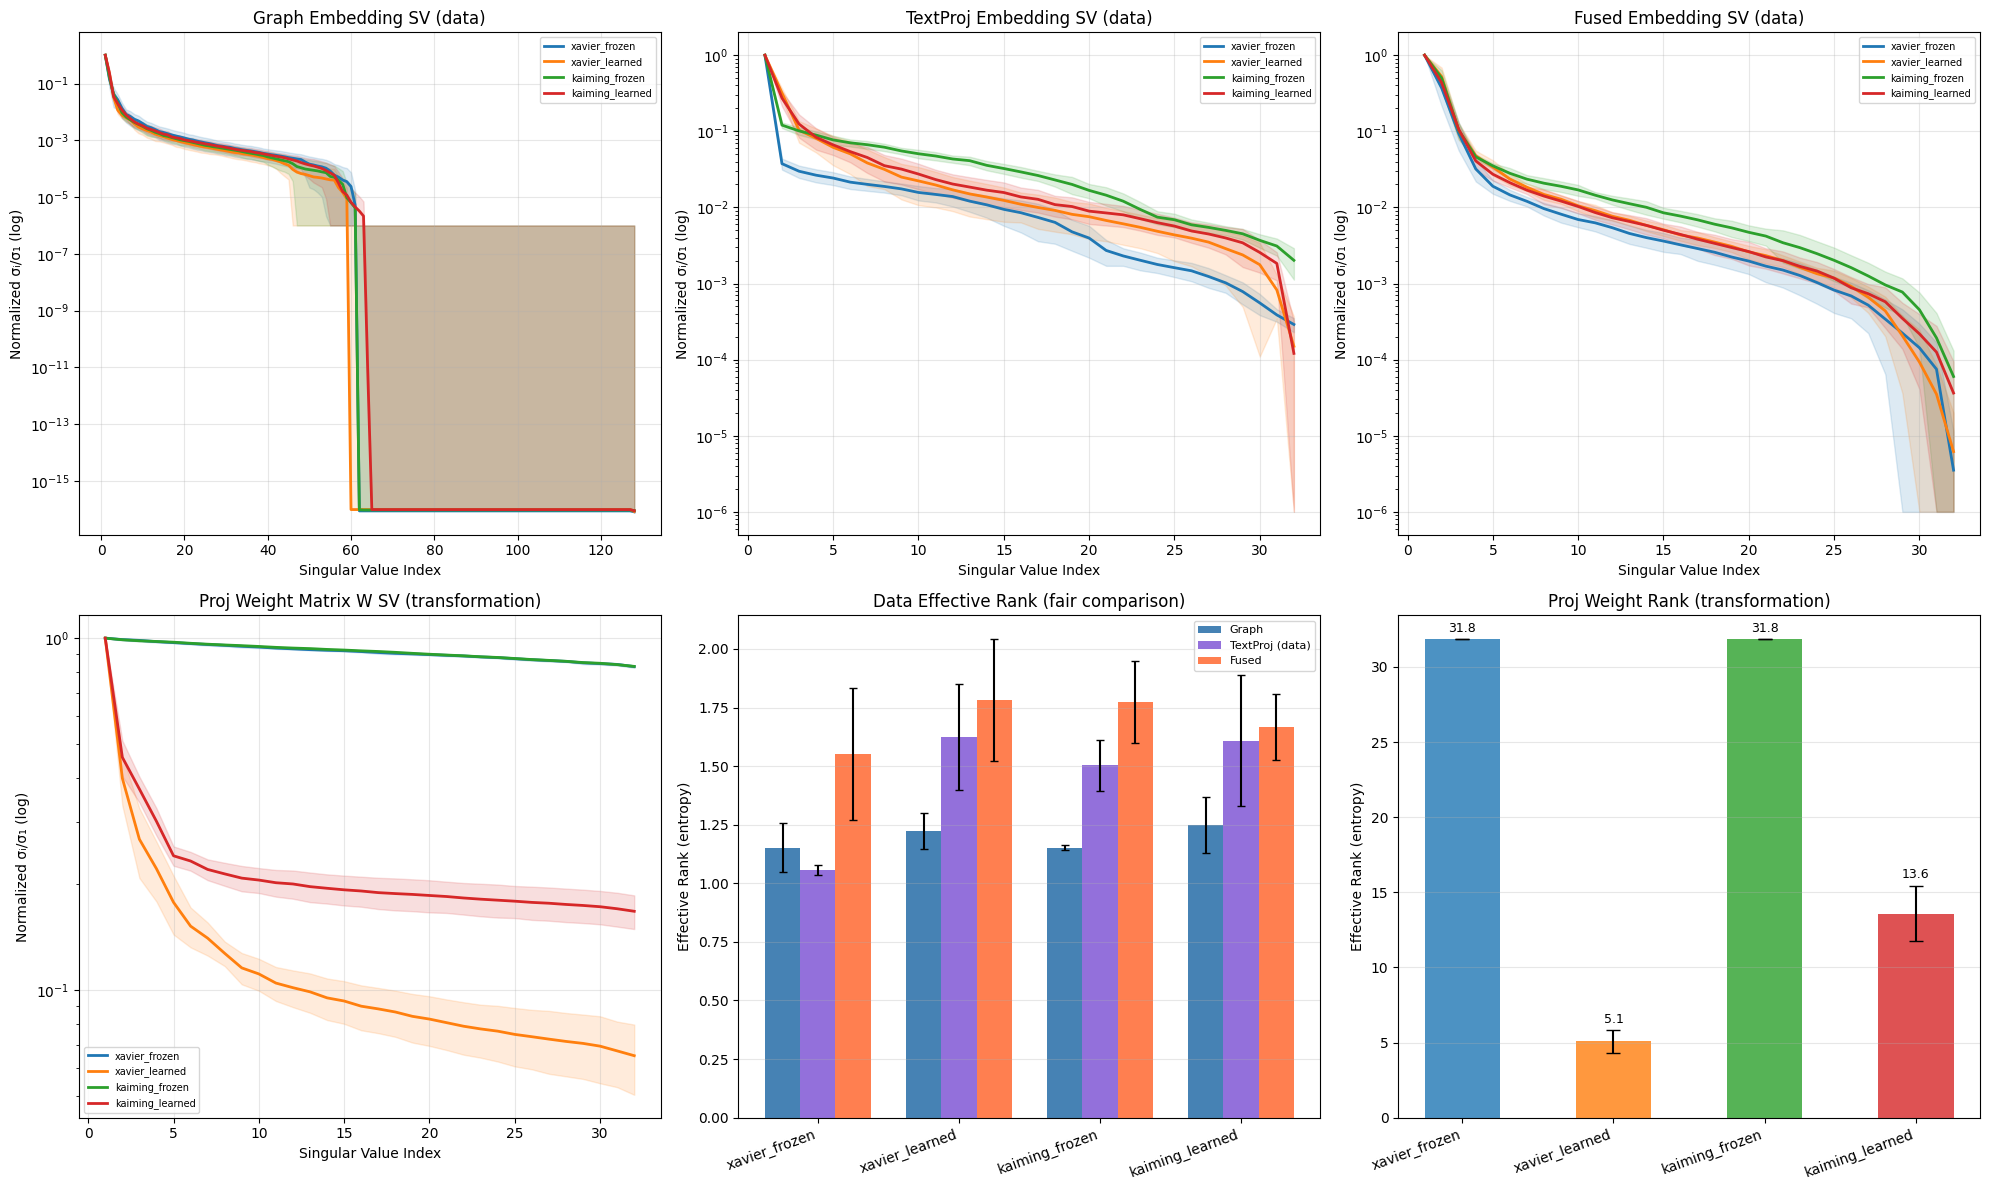


=== EFFECTIVE RANK SUMMARY ===

Config                Graph(data)  TextProj(data)  Fused(data)  Proj.W(weight)
--------------------------------------------------------------------------------
xavier_frozen          1.2±0.1       1.1±0.0     1.6±0.3          31.8±0.0
xavier_learned         1.2±0.1       1.6±0.2     1.8±0.3           5.1±0.7
kaiming_frozen         1.2±0.0       1.5±0.1     1.8±0.2          31.8±0.0
kaiming_learned        1.2±0.1       1.6±0.3     1.7±0.1          13.6±1.8

Max possible: graph=128, text_proj=32, proj_w=32


In [19]:
# === Effective Rank: Graph, TextProj-Data, Fused + Proj Weights ===
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
colors = {"xavier_frozen": "tab:blue", "xavier_learned": "tab:orange",
          "kaiming_frozen": "tab:green", "kaiming_learned": "tab:red"}

rank_summary = []
for config_name, seed_results in ALL_RESULTS.items():
    for seed, r in seed_results.items():
        eff_rank_graph = effective_rank(r["S_graph"])
        eff_rank_text = effective_rank(r["S_text_proj"])
        eff_rank_fused = effective_rank(r["S_fused"])
        eff_rank_proj_w = effective_rank(r["text_proj_weight_S"]) if r["text_proj_weight_S"] is not None else None
        rank_summary.append({
            "config": config_name, "seed": seed,
            "eff_rank_graph": eff_rank_graph, "eff_rank_text": eff_rank_text,
            "eff_rank_fused": eff_rank_fused, "eff_rank_proj_w": eff_rank_proj_w,
        })

# --- Plot 1: Graph Embedding SV ---
ax = axes[0, 0]
for config_name, seed_results in ALL_RESULTS.items():
    all_S = np.array([r["S_graph"] / r["S_graph"][0] for r in seed_results.values()])
    mean_S, std_S = all_S.mean(0), all_S.std(0)
    x = np.arange(1, len(mean_S) + 1)
    ax.semilogy(x, mean_S, '-', color=colors[config_name], linewidth=2, label=config_name)
    ax.fill_between(x, np.clip(mean_S - std_S, 1e-6, None), mean_S + std_S,
                     color=colors[config_name], alpha=0.15)
ax.set_xlabel("Singular Value Index")
ax.set_ylabel("Normalized \u03c3\u1d62/\u03c3\u2081 (log)")
ax.set_title("Graph Embedding SV (data)")
ax.legend(fontsize=7); ax.grid(alpha=0.3)

# --- Plot 2: TextProj Embedding SV (DATA, not weights!) ---
ax = axes[0, 1]
for config_name, seed_results in ALL_RESULTS.items():
    all_S = np.array([r["S_text_proj"] / r["S_text_proj"][0] for r in seed_results.values()])
    mean_S, std_S = all_S.mean(0), all_S.std(0)
    x = np.arange(1, len(mean_S) + 1)
    ax.semilogy(x, mean_S, '-', color=colors[config_name], linewidth=2, label=config_name)
    ax.fill_between(x, np.clip(mean_S - std_S, 1e-6, None), mean_S + std_S,
                     color=colors[config_name], alpha=0.15)
ax.set_xlabel("Singular Value Index")
ax.set_ylabel("Normalized \u03c3\u1d62/\u03c3\u2081 (log)")
ax.set_title("TextProj Embedding SV (data)")
ax.legend(fontsize=7); ax.grid(alpha=0.3)

# --- Plot 3: Fused Embedding SV ---
ax = axes[0, 2]
for config_name, seed_results in ALL_RESULTS.items():
    all_S = np.array([r["S_fused"] / r["S_fused"][0] for r in seed_results.values()])
    mean_S, std_S = all_S.mean(0), all_S.std(0)
    x = np.arange(1, len(mean_S) + 1)
    ax.semilogy(x, mean_S, '-', color=colors[config_name], linewidth=2, label=config_name)
    ax.fill_between(x, np.clip(mean_S - std_S, 1e-6, None), mean_S + std_S,
                     color=colors[config_name], alpha=0.15)
ax.set_xlabel("Singular Value Index")
ax.set_ylabel("Normalized \u03c3\u1d62/\u03c3\u2081 (log)")
ax.set_title("Fused Embedding SV (data)")
ax.legend(fontsize=7); ax.grid(alpha=0.3)

# --- Plot 4: Proj Weight Matrix SV ---
ax = axes[1, 0]
for config_name, seed_results in ALL_RESULTS.items():
    S_arrays = [r["text_proj_weight_S"] for r in seed_results.values() if r["text_proj_weight_S"] is not None]
    if S_arrays:
        all_S = np.array([S / S[0] for S in S_arrays])
        mean_S, std_S = all_S.mean(0), all_S.std(0)
        x = np.arange(1, len(mean_S) + 1)
        ax.semilogy(x, mean_S, '-', color=colors[config_name], linewidth=2, label=config_name)
        ax.fill_between(x, np.clip(mean_S - std_S, 1e-6, None), mean_S + std_S,
                         color=colors[config_name], alpha=0.15)
ax.set_xlabel("Singular Value Index")
ax.set_ylabel("Normalized \u03c3\u1d62/\u03c3\u2081 (log)")
ax.set_title("Proj Weight Matrix W SV (transformation)")
ax.legend(fontsize=7); ax.grid(alpha=0.3)

# --- Plot 5: Data Effective Rank Bar Chart ---
ax = axes[1, 1]
rank_df = pd.DataFrame(rank_summary)
config_order = ["xavier_frozen", "xavier_learned", "kaiming_frozen", "kaiming_learned"]
rank_agg = rank_df.groupby("config").agg(
    graph_mean=("eff_rank_graph", "mean"), graph_std=("eff_rank_graph", "std"),
    text_mean=("eff_rank_text", "mean"), text_std=("eff_rank_text", "std"),
    fused_mean=("eff_rank_fused", "mean"), fused_std=("eff_rank_fused", "std"),
).reindex(config_order)
x = np.arange(len(rank_agg))
width = 0.25
ax.bar(x - width, rank_agg["graph_mean"], width, yerr=rank_agg["graph_std"],
       label="Graph", color="steelblue", capsize=3)
ax.bar(x, rank_agg["text_mean"], width, yerr=rank_agg["text_std"],
       label="TextProj (data)", color="mediumpurple", capsize=3)
ax.bar(x + width, rank_agg["fused_mean"], width, yerr=rank_agg["fused_std"],
       label="Fused", color="coral", capsize=3)
ax.set_xticks(x)
ax.set_xticklabels(rank_agg.index, rotation=20, ha="right")
ax.set_ylabel("Effective Rank (entropy)")
ax.set_title("Data Effective Rank (fair comparison)")
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis="y")

# --- Plot 6: Weight Effective Rank Bar Chart ---
ax = axes[1, 2]
rank_agg_w = rank_df.groupby("config").agg(
    proj_w_mean=("eff_rank_proj_w", "mean"), proj_w_std=("eff_rank_proj_w", "std"),
).reindex(config_order)
ax.bar(x, rank_agg_w["proj_w_mean"], 0.5, yerr=rank_agg_w["proj_w_std"],
       color=[colors[c] for c in config_order], capsize=5, alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(config_order, rotation=20, ha="right")
ax.set_ylabel("Effective Rank (entropy)")
ax.set_title("Proj Weight Rank (transformation)")
ax.grid(alpha=0.3, axis="y")
for i, (m, s) in enumerate(zip(rank_agg_w["proj_w_mean"], rank_agg_w["proj_w_std"])):
    if not np.isnan(m):
        ax.text(i, m + s + 0.3, f"{m:.1f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

# Summary table
print("\n=== EFFECTIVE RANK SUMMARY ===\n")
print(f"{'Config':<20} {'Graph(data)':>12} {'TextProj(data)':>15} {'Fused(data)':>12} {'Proj.W(weight)':>15}")
print("-" * 80)
for c in config_order:
    rg = rank_agg.loc[c]
    rw = rank_agg_w.loc[c]
    pw_str = f"{rw['proj_w_mean']:.1f}\u00b1{rw['proj_w_std']:.1f}" if not np.isnan(rw['proj_w_mean']) else "N/A"
    print(f"{c:<20} {rg['graph_mean']:>5.1f}\u00b1{rg['graph_std']:<4.1f}  "
          f"{rg['text_mean']:>7.1f}\u00b1{rg['text_std']:<4.1f}  "
          f"{rg['fused_mean']:>5.1f}\u00b1{rg['fused_std']:<4.1f}  "
          f"{pw_str:>15}")
print(f"\nMax possible: graph={BASE_CONFIG['hidden_channels']}, "
      f"text_proj={BASE_CONFIG['text_projection_dim']}, proj_w={BASE_CONFIG['text_projection_dim']}")

---
### 2b. Johnson-Lindenstrauss Distance Preservation Test

Bleiben paarweise Distanzen bei der Projektion 3072D → 64D erhalten?  
Zusätzlich: Trainable-Parameter-Vergleich.

Original text embeddings: (152, 3072)
Pairwise distances: 11476 pairs



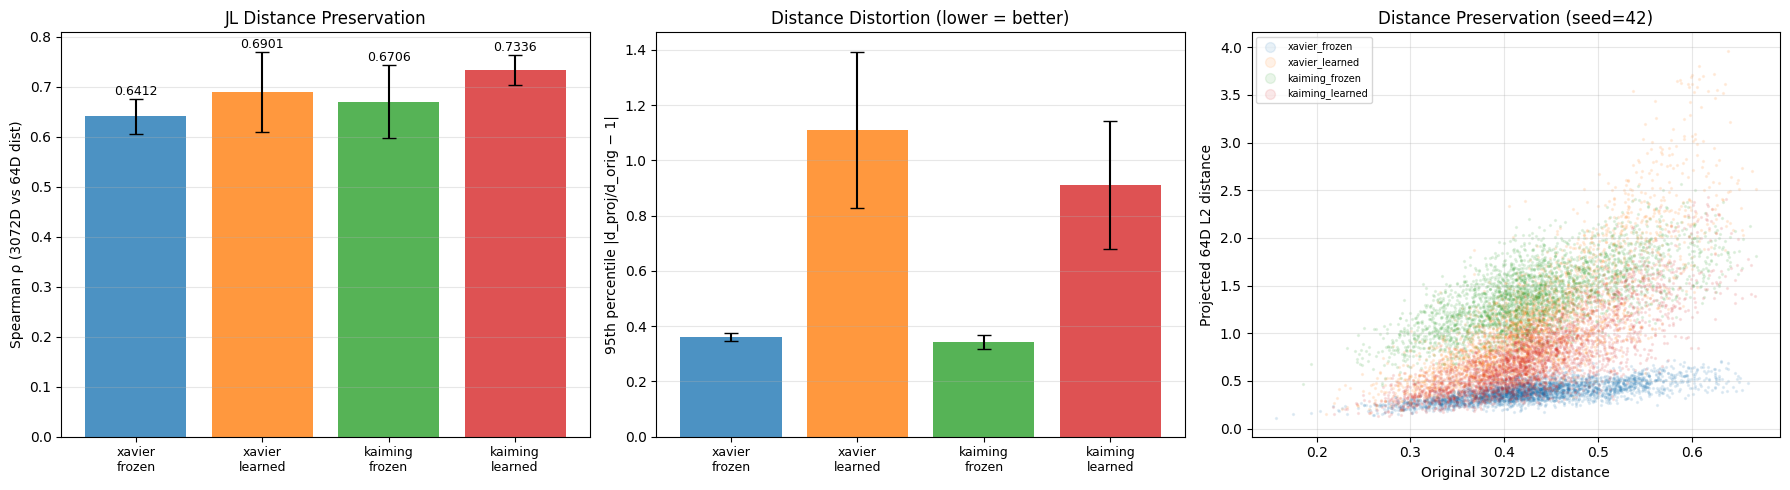


=== TRAINABLE PARAMETER COUNT ===

  xavier_frozen        total= 225,825  trainable= 127,425  frozen=  98,400  (56% trainable)
  xavier_learned       total= 225,825  trainable= 225,825  frozen=       0  (100% trainable)
  kaiming_frozen       total= 225,825  trainable= 127,425  frozen=  98,400  (56% trainable)
  kaiming_learned      total= 225,825  trainable= 225,825  frozen=       0  (100% trainable)

=== JL DISTANCE PRESERVATION SUMMARY ===

Config                   Spearman ρ   95% Distortion
-------------------------------------------------------
  xavier_frozen        0.6412±0.0354   0.361±0.015
  xavier_learned       0.6901±0.0805   1.111±0.283
  kaiming_frozen       0.6706±0.0723   0.344±0.025
  kaiming_learned      0.7336±0.0297   0.912±0.232


In [20]:
# === JL Distance Preservation + Parameter Count ===

# --- 1. Pairwise distances in original 3072D ---
text_emb_np = TEST_TEXT_EMB.numpy()
dist_original = pdist(text_emb_np, metric="euclidean")
print(f"Original text embeddings: {text_emb_np.shape}")
print(f"Pairwise distances: {len(dist_original)} pairs\n")

# --- 2. Compare projected distances ---
jl_results = []
config_order = ["xavier_frozen", "xavier_learned", "kaiming_frozen", "kaiming_learned"]
for config_name, seed_results in ALL_RESULTS.items():
    for seed, r in seed_results.items():
        proj_emb = r["text_proj_emb"]
        dist_proj = pdist(proj_emb, metric="euclidean")
        rho, pval = spearmanr(dist_original, dist_proj)
        ratio = dist_proj / (dist_original + 1e-10)
        median_ratio = np.median(ratio)
        normalized = ratio / median_ratio
        p95_distortion = np.percentile(np.abs(normalized - 1.0), 95)
        jl_results.append({
            "config": config_name, "seed": seed,
            "spearman_rho": rho, "p95_distortion": p95_distortion,
        })

jl_df = pd.DataFrame(jl_results)

# --- Plots ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
means = [jl_df[jl_df["config"] == c]["spearman_rho"].mean() for c in config_order]
stds = [jl_df[jl_df["config"] == c]["spearman_rho"].std() for c in config_order]
ax.bar(range(4), means, yerr=stds, capsize=5,
       color=[colors[c] for c in config_order], alpha=0.8)
ax.set_xticks(range(4))
ax.set_xticklabels([c.replace("_", "\n") for c in config_order], fontsize=9)
ax.set_ylabel("Spearman \u03c1 (3072D vs 64D dist)")
ax.set_title("JL Distance Preservation")
ax.grid(alpha=0.3, axis="y")
for i, (m, s) in enumerate(zip(means, stds)):
    ax.text(i, m + s + 0.002, f"{m:.4f}", ha="center", va="bottom", fontsize=9)

ax = axes[1]
means = [jl_df[jl_df["config"] == c]["p95_distortion"].mean() for c in config_order]
stds = [jl_df[jl_df["config"] == c]["p95_distortion"].std() for c in config_order]
ax.bar(range(4), means, yerr=stds, capsize=5,
       color=[colors[c] for c in config_order], alpha=0.8)
ax.set_xticks(range(4))
ax.set_xticklabels([c.replace("_", "\n") for c in config_order], fontsize=9)
ax.set_ylabel("95th percentile |d_proj/d_orig \u2212 1|")
ax.set_title("Distance Distortion (lower = better)")
ax.grid(alpha=0.3, axis="y")

ax = axes[2]
seed0 = min(ALL_RESULTS["xavier_frozen"].keys())
for config_name in config_order:
    r = ALL_RESULTS[config_name][seed0]
    dist_proj = pdist(r["text_proj_emb"], metric="euclidean")
    n_pairs = len(dist_original)
    idx_sub = np.random.choice(n_pairs, min(3000, n_pairs), replace=False)
    ax.scatter(dist_original[idx_sub], dist_proj[idx_sub], alpha=0.1, s=2,
               label=config_name, rasterized=True)
ax.set_xlabel("Original 3072D L2 distance")
ax.set_ylabel("Projected 64D L2 distance")
ax.set_title(f"Distance Preservation (seed={seed0})")
ax.legend(fontsize=7, markerscale=5); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# --- Parameter Count ---
print("\n=== TRAINABLE PARAMETER COUNT ===\n")
seed0 = min(ALL_RESULTS["xavier_frozen"].keys())
for config_name in config_order:
    model = ALL_RESULTS[config_name][seed0]["model"]
    total = sum(p.numel() for p in model._encoder.parameters())
    total += sum(p.numel() for p in model._pooling.parameters())
    total += sum(p.numel() for p in model._fusion.parameters())
    total += sum(p.numel() for p in model._head.parameters())
    text_proj_params = 0
    if model._text_proj:
        text_proj_params = sum(p.numel() for p in model._text_proj.parameters())
        total += text_proj_params
    frozen_p = text_proj_params if model.config.freeze_text_proj else 0
    trainable = total - frozen_p
    print(f"  {config_name:<20} total={total:>8,}  trainable={trainable:>8,}  frozen={frozen_p:>8,}  "
          f"({100*trainable/total:.0f}% trainable)")

# --- JL Summary ---
print("\n=== JL DISTANCE PRESERVATION SUMMARY ===\n")
jl_summary = jl_df.groupby("config").agg(
    rho_mean=("spearman_rho", "mean"), rho_std=("spearman_rho", "std"),
    dist95_mean=("p95_distortion", "mean"), dist95_std=("p95_distortion", "std"),
).reindex(config_order)
print(f"{'Config':<20} {'Spearman \u03c1':>14} {'95% Distortion':>16}")
print("-" * 55)
for c, row in jl_summary.iterrows():
    print(f"  {c:<20} {row['rho_mean']:.4f}\u00b1{row['rho_std']:.4f}   {row['dist95_mean']:.3f}\u00b1{row['dist95_std']:.3f}")

---
## 3. Embedding Stability Across Seeds (CKA)

Linear CKA (Kornblith 2019) für Graph, TextProj und Fused Embeddings.

\u26a0 **Caveat:** Bei frozen text\_proj hat jeder Seed eine andere zufällige Projektion.  
Niedrige TextProj-CKA für frozen ist Artefakt, kein Qualitätsproblem.

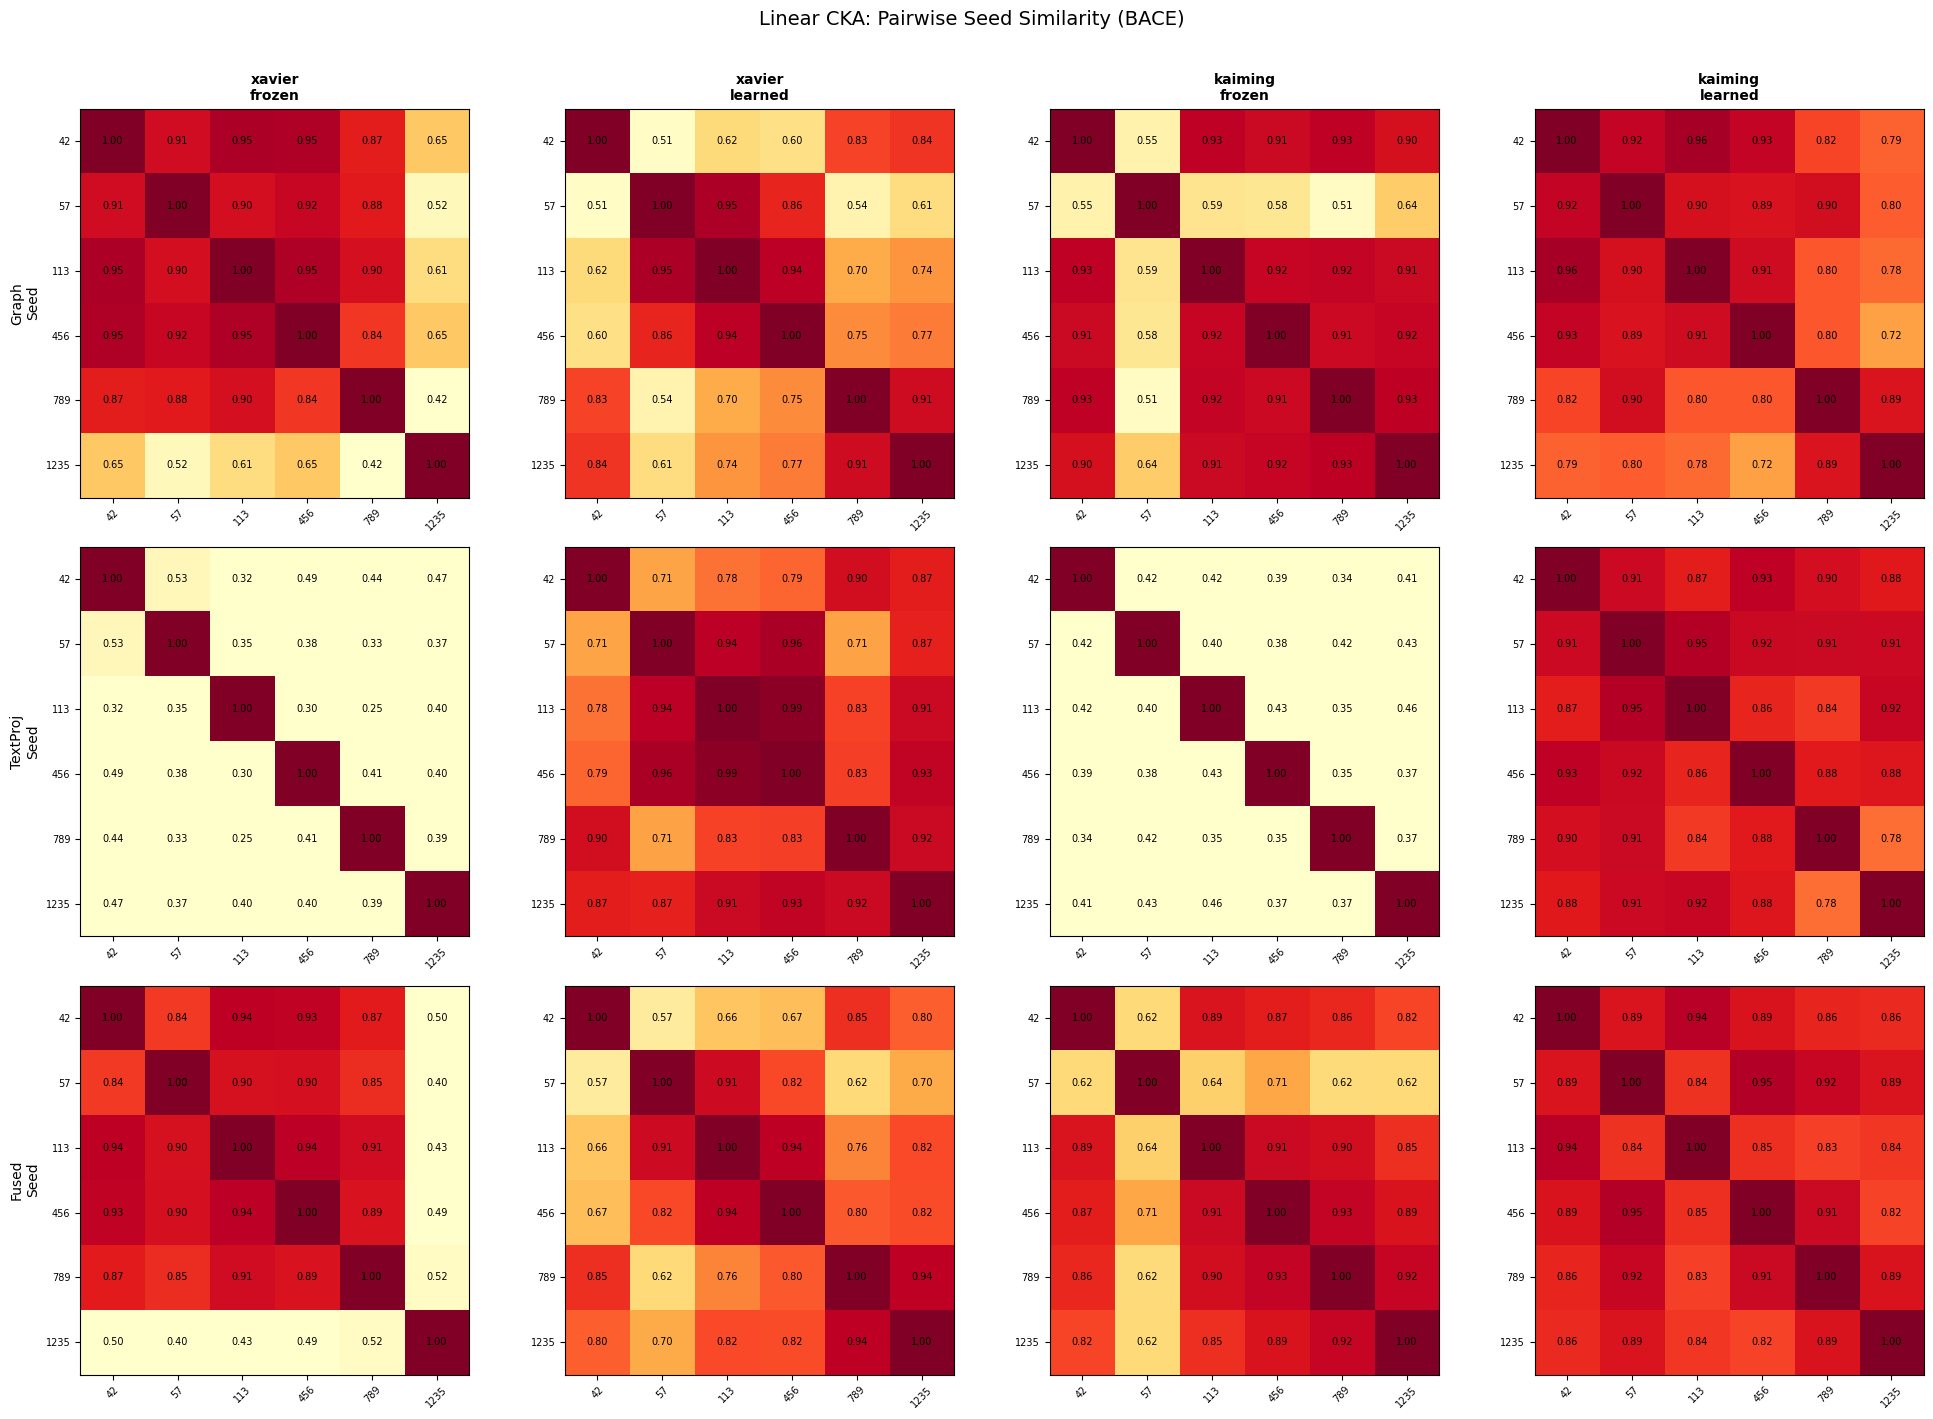


=== CKA SUMMARY (off-diagonal mean ± std) ===

Config                  Graph CKA   TextProj CKA    Fused CKA
-----------------------------------------------------------------
xavier_frozen         0.795±0.169    0.389±0.069    0.753±0.205  
xavier_learned        0.744±0.139    0.862±0.082    0.777±0.110  
kaiming_frozen        0.806±0.165    0.396±0.034    0.804±0.119  
kaiming_learned       0.855±0.067    0.890±0.040    0.879±0.038  


In [21]:
# === CKA Embedding Stability ===

def linear_CKA(X, Y):
    X = X - X.mean(0)
    Y = Y - Y.mean(0)
    hsic_xy = np.linalg.norm(X.T @ Y, 'fro')**2
    hsic_xx = np.linalg.norm(X.T @ X, 'fro')**2
    hsic_yy = np.linalg.norm(Y.T @ Y, 'fro')**2
    return hsic_xy / (np.sqrt(hsic_xx * hsic_yy) + 1e-10)

cka_results = {}
config_order = ["xavier_frozen", "xavier_learned", "kaiming_frozen", "kaiming_learned"]
for config_name, seed_results in ALL_RESULTS.items():
    seeds = sorted(seed_results.keys())
    n = len(seeds)
    for emb_type in ["graph_emb", "text_proj_emb", "fused_emb"]:
        emb_list = [seed_results[s][emb_type] for s in seeds]
        cka_matrix = np.ones((n, n))
        for i in range(n):
            for j in range(i+1, n):
                c = linear_CKA(emb_list[i], emb_list[j])
                cka_matrix[i, j] = c
                cka_matrix[j, i] = c
        cka_results[(config_name, emb_type)] = cka_matrix

# --- 3×4 Heatmaps ---
fig, axes = plt.subplots(3, 4, figsize=(20, 14))
for col, config_name in enumerate(config_order):
    for row, (emb_type, emb_label) in enumerate([
        ("graph_emb", "Graph"), ("text_proj_emb", "TextProj"), ("fused_emb", "Fused")
    ]):
        ax = axes[row, col]
        cka = cka_results[(config_name, emb_type)]
        seeds = sorted(ALL_RESULTS[config_name].keys())
        ax.imshow(cka, vmin=0.5, vmax=1.0, cmap="YlOrRd")
        ax.set_xticks(range(len(seeds)))
        ax.set_xticklabels(seeds, fontsize=7, rotation=45)
        ax.set_yticks(range(len(seeds)))
        ax.set_yticklabels(seeds, fontsize=7)
        for i in range(len(seeds)):
            for j in range(len(seeds)):
                ax.text(j, i, f"{cka[i,j]:.2f}", ha="center", va="center", fontsize=7)
        if row == 0:
            ax.set_title(config_name.replace("_", "\n"), fontsize=10, fontweight="bold")
        if col == 0:
            ax.set_ylabel(f"{emb_label}\nSeed", fontsize=10)

fig.suptitle("Linear CKA: Pairwise Seed Similarity (BACE)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Summary
print("\n=== CKA SUMMARY (off-diagonal mean \u00b1 std) ===\n")
print(f"{'Config':<20} {'Graph CKA':>12} {'TextProj CKA':>14} {'Fused CKA':>12}")
print("-" * 65)
for config_name in config_order:
    row_str = f"{config_name:<20}"
    for emb_type in ["graph_emb", "text_proj_emb", "fused_emb"]:
        cka = cka_results[(config_name, emb_type)]
        off_diag = cka[np.triu_indices_from(cka, k=1)]
        row_str += f"  {off_diag.mean():.3f}\u00b1{off_diag.std():.3f}  "
    print(row_str)

---
## 4. Tanimoto & |\u0394y| vs. Embedding Distance Correlation

1. **Tanimoto \u2194 CosSim** — strukturelle \u00c4hnlichkeit (Morgan FP)
2. **|\u0394y| \u2194 L2-Distanz** — task-relevante \u00c4hnlichkeit

Bei bin\u00e4rer Klassifikation: |\u0394y| \u2208 {0, 1} (same-class vs different-class).  
\u2192 Die |\u0394y|-Korrelation misst hier: *Trennen die Embeddings die Klassen?*

Test set: 152 molecules, 11476 pairs
|Δy| distribution: 5956 same-class, 5520 cross-class


[01:27:40] DEPRECATION WARNING: please use MorganGenerator
[01:27:40] DEPRECATION WARNING: please use MorganGenerator
[01:27:40] DEPRECATION WARNING: please use MorganGenerator
[01:27:40] DEPRECATION WARNING: please use MorganGenerator
[01:27:40] DEPRECATION WARNING: please use MorganGenerator
[01:27:40] DEPRECATION WARNING: please use MorganGenerator
[01:27:40] DEPRECATION WARNING: please use MorganGenerator
[01:27:40] DEPRECATION WARNING: please use MorganGenerator
[01:27:40] DEPRECATION WARNING: please use MorganGenerator
[01:27:40] DEPRECATION WARNING: please use MorganGenerator
[01:27:40] DEPRECATION WARNING: please use MorganGenerator
[01:27:40] DEPRECATION WARNING: please use MorganGenerator
[01:27:40] DEPRECATION WARNING: please use MorganGenerator
[01:27:40] DEPRECATION WARNING: please use MorganGenerator
[01:27:40] DEPRECATION WARNING: please use MorganGenerator
[01:27:40] DEPRECATION WARNING: please use MorganGenerator
[01:27:40] DEPRECATION WARNING: please use MorganGenerat

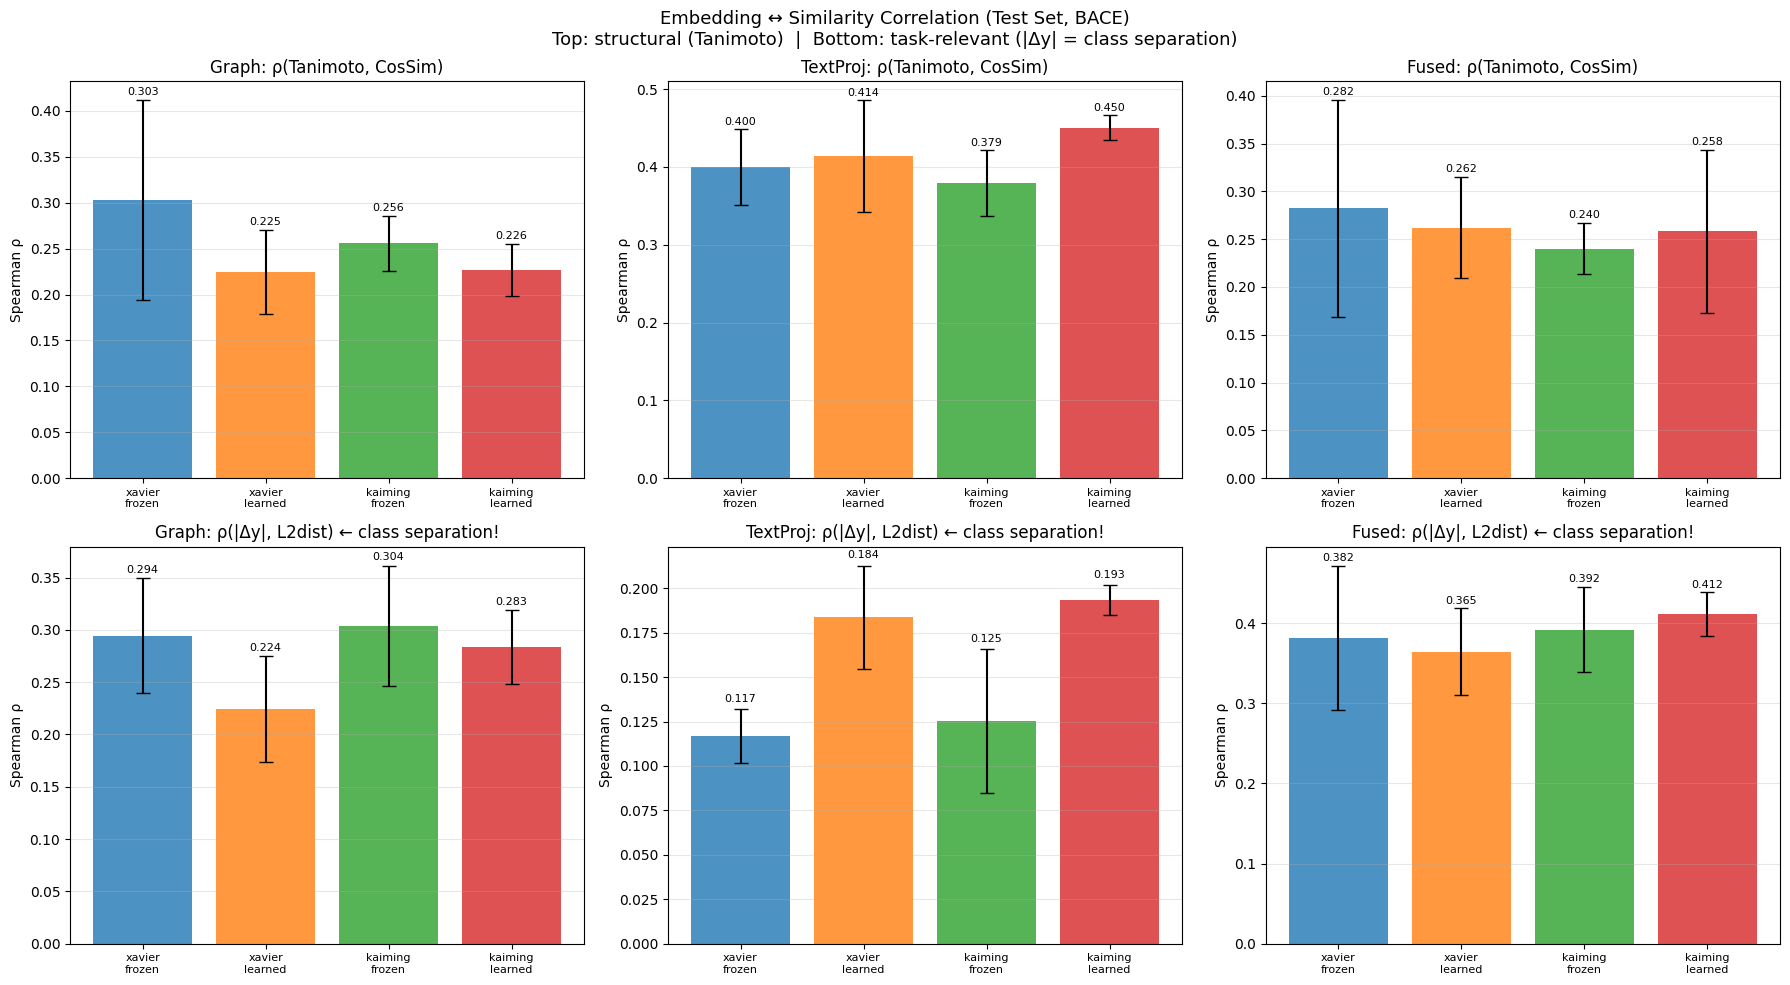

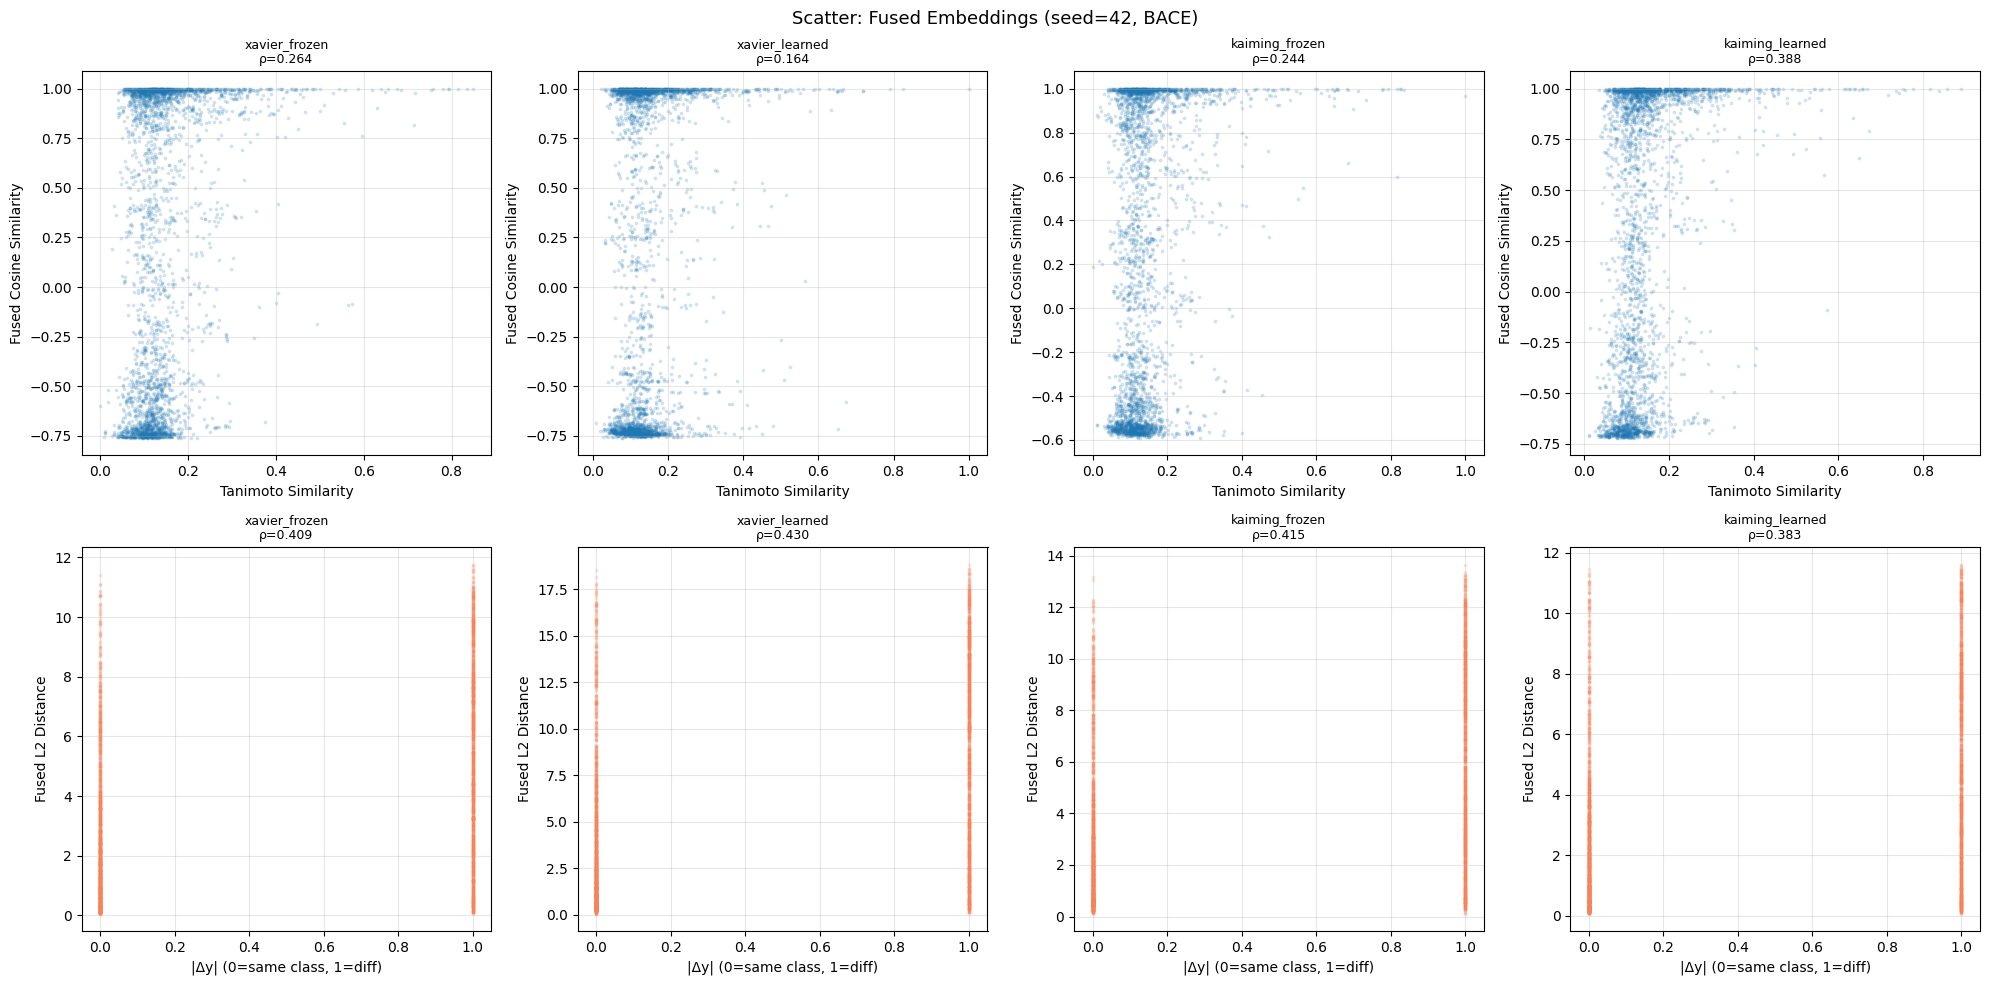


=== CORRELATION SUMMARY ===

--- Tanimoto Correlation ---
                   mean                      std                 
embedding         Fused   Graph TextProj   Fused   Graph TextProj
config                                                           
kaiming_frozen   0.2402  0.2558   0.3791  0.0265  0.0301   0.0421
kaiming_learned  0.2580  0.2265   0.4504  0.0856  0.0285   0.0164
xavier_frozen    0.2821  0.3028   0.3997  0.1134  0.1091   0.0491
xavier_learned   0.2621  0.2249   0.4137  0.0530  0.0458   0.0723

--- |Δy| Correlation ---
                   mean                      std                 
embedding         Fused   Graph TextProj   Fused   Graph TextProj
config                                                           
kaiming_frozen   0.3921  0.3037   0.1252  0.0534  0.0576   0.0406
kaiming_learned  0.4116  0.2834   0.1934  0.0270  0.0353   0.0085
xavier_frozen    0.3821  0.2945   0.1167  0.0899  0.0552   0.0152
xavier_learned   0.3647  0.2243   0.1836  0.0544  0.0507 

In [22]:
# === Tanimoto & |Δy| Correlation ===
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs

# Tanimoto on test set
test_mols = [Chem.MolFromSmiles(s) for s in TEST_SMILES]
test_fps = [AllChem.GetMorganFingerprintAsBitVect(m, 2, nBits=2048) for m in test_mols if m is not None]
n_test = len(test_fps)

tanimoto_sim = []
for i in range(n_test):
    for j in range(i + 1, n_test):
        tanimoto_sim.append(DataStructs.TanimotoSimilarity(test_fps[i], test_fps[j]))
tanimoto_sim = np.array(tanimoto_sim)

# |Δy| — for binary labels this is 0 (same class) or 1 (different class)
delta_y = pdist(TEST_Y.reshape(-1, 1), metric="euclidean")

print(f"Test set: {n_test} molecules, {len(tanimoto_sim)} pairs")
print(f"|Δy| distribution: {(delta_y == 0).sum()} same-class, {(delta_y > 0).sum()} cross-class")

# Correlations per config/seed/embedding
corr_results = []
config_order = ["xavier_frozen", "xavier_learned", "kaiming_frozen", "kaiming_learned"]
for config_name, seed_results in ALL_RESULTS.items():
    for seed, r in seed_results.items():
        for emb_key, emb_label in [("graph_emb", "Graph"), ("text_proj_emb", "TextProj"), ("fused_emb", "Fused")]:
            emb = r[emb_key]
            if len(emb) != n_test:
                continue
            cos_sim = 1.0 - pdist(emb, metric="cosine")
            emb_l2 = pdist(emb, metric="euclidean")
            rho_tan, _ = spearmanr(tanimoto_sim, cos_sim)
            rho_dy, _ = spearmanr(delta_y, emb_l2)
            corr_results.append({
                "config": config_name, "seed": seed, "embedding": emb_label,
                "rho_tanimoto": rho_tan, "rho_delta_y": rho_dy,
            })

corr_df = pd.DataFrame(corr_results)

# --- Bar charts ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
emb_labels = ["Graph", "TextProj", "Fused"]
for col, emb_label in enumerate(emb_labels):
    sub = corr_df[corr_df["embedding"] == emb_label]
    # Row 0: Tanimoto
    ax = axes[0, col]
    means = [sub[sub["config"] == c]["rho_tanimoto"].mean() for c in config_order]
    stds = [sub[sub["config"] == c]["rho_tanimoto"].std() for c in config_order]
    ax.bar(range(4), means, yerr=stds, capsize=5,
           color=[colors[c] for c in config_order], alpha=0.8)
    ax.set_xticks(range(4))
    ax.set_xticklabels([c.replace("_", "\n") for c in config_order], fontsize=8)
    ax.set_ylabel("Spearman \u03c1")
    ax.set_title(f"{emb_label}: \u03c1(Tanimoto, CosSim)")
    ax.grid(alpha=0.3, axis="y")
    for i, (m, s) in enumerate(zip(means, stds)):
        ax.text(i, m + s + 0.003, f"{m:.3f}", ha="center", va="bottom", fontsize=8)
    # Row 1: |Δy|
    ax = axes[1, col]
    means = [sub[sub["config"] == c]["rho_delta_y"].mean() for c in config_order]
    stds = [sub[sub["config"] == c]["rho_delta_y"].std() for c in config_order]
    ax.bar(range(4), means, yerr=stds, capsize=5,
           color=[colors[c] for c in config_order], alpha=0.8)
    ax.set_xticks(range(4))
    ax.set_xticklabels([c.replace("_", "\n") for c in config_order], fontsize=8)
    ax.set_ylabel("Spearman \u03c1")
    ax.set_title(f"{emb_label}: \u03c1(|\u0394y|, L2dist) \u2190 class separation!")
    ax.grid(alpha=0.3, axis="y")
    for i, (m, s) in enumerate(zip(means, stds)):
        ax.text(i, m + s + 0.003, f"{m:.3f}", ha="center", va="bottom", fontsize=8)

fig.suptitle("Embedding \u2194 Similarity Correlation (Test Set, BACE)\n"
             "Top: structural (Tanimoto)  |  Bottom: task-relevant (|\u0394y| = class separation)", fontsize=13)
plt.tight_layout()
plt.show()

# Scatter for fused embeddings, first seed
seed0 = min(ALL_RESULTS["xavier_frozen"].keys())
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for col, config_name in enumerate(config_order):
    r = ALL_RESULTS[config_name][seed0]
    fused_emb = r["fused_emb"]
    fused_l2 = pdist(fused_emb, metric="euclidean")
    n_pairs = len(tanimoto_sim)
    idx_sub = np.random.choice(n_pairs, min(3000, n_pairs), replace=False)
    # Tanimoto scatter
    ax = axes[0, col]
    cos_sim = 1.0 - pdist(fused_emb, metric="cosine")
    ax.scatter(tanimoto_sim[idx_sub], cos_sim[idx_sub], alpha=0.15, s=3, rasterized=True)
    rho, _ = spearmanr(tanimoto_sim[idx_sub], cos_sim[idx_sub])
    ax.set_xlabel("Tanimoto Similarity")
    ax.set_ylabel("Fused Cosine Similarity")
    ax.set_title(f"{config_name}\n\u03c1={rho:.3f}", fontsize=9)
    ax.grid(alpha=0.3)
    # |Δy| scatter
    ax = axes[1, col]
    ax.scatter(delta_y[idx_sub], fused_l2[idx_sub], alpha=0.15, s=3, c="coral", rasterized=True)
    rho, _ = spearmanr(delta_y[idx_sub], fused_l2[idx_sub])
    ax.set_xlabel("|\u0394y| (0=same class, 1=diff)")
    ax.set_ylabel("Fused L2 Distance")
    ax.set_title(f"{config_name}\n\u03c1={rho:.3f}", fontsize=9)
    ax.grid(alpha=0.3)

fig.suptitle(f"Scatter: Fused Embeddings (seed={seed0}, BACE)", fontsize=13)
plt.tight_layout()
plt.show()

# Summary
print("\n=== CORRELATION SUMMARY ===\n")
for metric_col, metric_name in [("rho_tanimoto", "Tanimoto"), ("rho_delta_y", "|\u0394y|")]:
    print(f"--- {metric_name} Correlation ---")
    pivot = corr_df.groupby(["config", "embedding"])[metric_col].agg(["mean", "std"])
    pivot = pivot.unstack()
    print(pivot.round(4))
    print()

---
## 5. Learning Curves: Frozen vs Learned

Train BCE vs Val BCE. Für Klassifikation: kein sqrt nötig (BCE ist direkt vergleichbar).

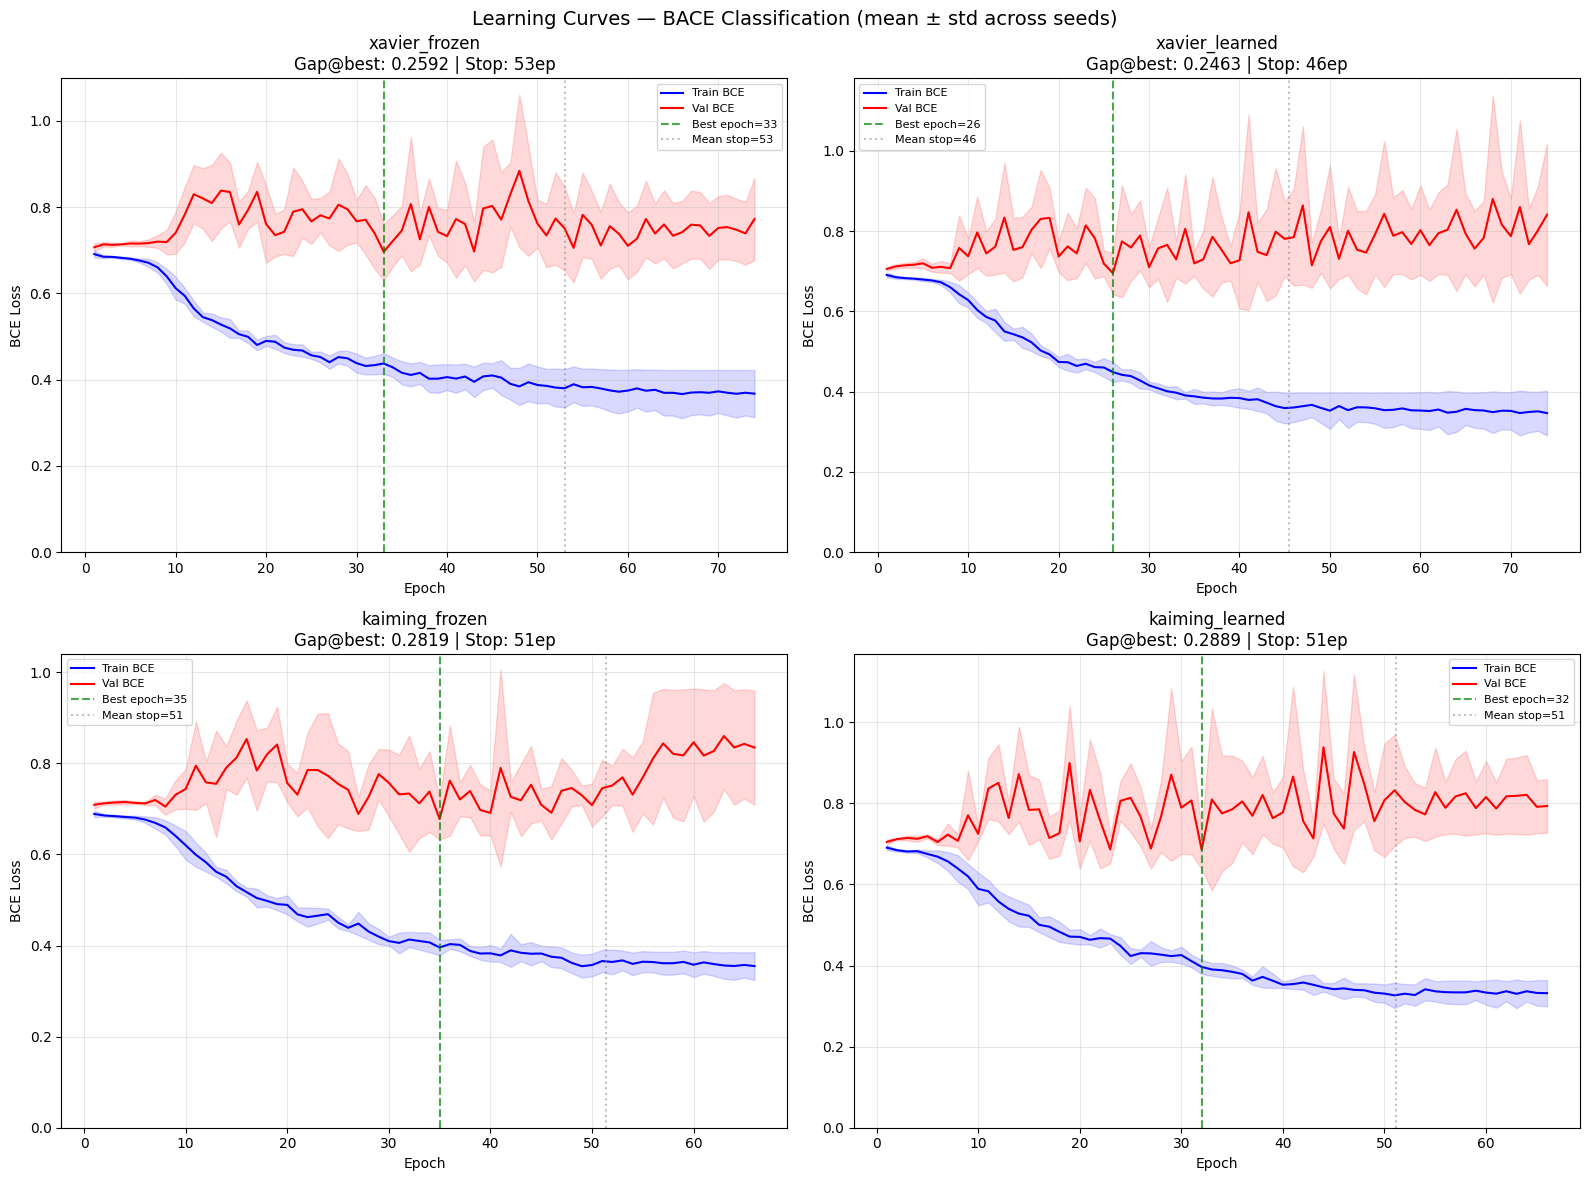


=== GENERALIZATION GAP SUMMARY (BCE) ===

Config                 Best Val BCE   Train@Best   Gap@Best   Epochs     Stop
--------------------------------------------------------------------------------
xavier_frozen         0.6413±0.0337  0.4674±0.1056     0.1739       53       74
xavier_learned        0.6395±0.0144  0.4919±0.0979     0.1476       46       74
kaiming_frozen        0.6283±0.0296  0.4553±0.0814     0.1731       51       66
kaiming_learned       0.6336±0.0136  0.4273±0.0361     0.2063       51       66


In [23]:
# === Learning Curves ===
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
config_order = ["xavier_frozen", "xavier_learned", "kaiming_frozen", "kaiming_learned"]

for idx, config_name in enumerate(config_order):
    ax = axes[idx // 2, idx % 2]
    seed_results = ALL_RESULTS[config_name]

    all_train = []
    all_val = []
    for seed, r in seed_results.items():
        h = r["history"]
        all_train.append(h["train_loss"])
        all_val.append(h["val_metric"])  # BCE for classification

    max_len = max(len(t) for t in all_train)
    for i in range(len(all_train)):
        last_train = all_train[i][-1]
        last_val = all_val[i][-1]
        all_train[i] = all_train[i] + [last_train] * (max_len - len(all_train[i]))
        all_val[i] = all_val[i] + [last_val] * (max_len - len(all_val[i]))

    all_train = np.array(all_train)
    all_val = np.array(all_val)
    epochs = np.arange(1, max_len + 1)

    # For classification, train_loss is BCE and val_metric is BCE — directly comparable
    ax.plot(epochs, all_train.mean(0), 'b-', linewidth=1.5, label="Train BCE")
    ax.fill_between(epochs, all_train.mean(0) - all_train.std(0),
                    all_train.mean(0) + all_train.std(0), alpha=0.15, color="blue")
    ax.plot(epochs, all_val.mean(0), 'r-', linewidth=1.5, label="Val BCE")
    ax.fill_between(epochs, all_val.mean(0) - all_val.std(0),
                    all_val.mean(0) + all_val.std(0), alpha=0.15, color="red")

    gap = all_val.mean(0) - all_train.mean(0)
    best_epoch_idx = np.argmin(all_val.mean(0))
    actual_lengths = [len(r["history"]["train_loss"]) for r in seed_results.values()]
    mean_stop = np.mean(actual_lengths)
    gap_at_best = gap[best_epoch_idx]

    ax.axvline(best_epoch_idx + 1, color="green", linestyle="--", alpha=0.7,
               label=f"Best epoch={best_epoch_idx+1}")
    ax.axvline(mean_stop, color="gray", linestyle=":", alpha=0.5,
               label=f"Mean stop={mean_stop:.0f}")

    ax.set_xlabel("Epoch")
    ax.set_ylabel("BCE Loss")
    ax.set_title(f"{config_name}\nGap@best: {gap_at_best:.4f} | Stop: {mean_stop:.0f}ep")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.set_ylim(bottom=0)

plt.suptitle("Learning Curves — BACE Classification (mean \u00b1 std across seeds)", fontsize=14)
plt.tight_layout()
plt.show()

# Gap Summary
print("\n=== GENERALIZATION GAP SUMMARY (BCE) ===\n")
print(f"{'Config':<20} {'Best Val BCE':>14} {'Train@Best':>12} {'Gap@Best':>10} {'Epochs':>8} {'Stop':>8}")
print("-" * 80)
for config_name in config_order:
    seed_results = ALL_RESULTS[config_name]
    best_val_per_seed = []
    train_at_best_per_seed = []
    n_epochs_per_seed = []
    for r in seed_results.values():
        val_bce = r["history"]["val_metric"]
        train_bce = r["history"]["train_loss"]
        best_idx = np.argmin(val_bce)
        best_val_per_seed.append(val_bce[best_idx])
        train_at_best_per_seed.append(train_bce[best_idx])
        n_epochs_per_seed.append(len(train_bce))
    bv = np.mean(best_val_per_seed)
    tb = np.mean(train_at_best_per_seed)
    gap = bv - tb
    epochs_mean = np.mean(n_epochs_per_seed)
    max_ep = max(n_epochs_per_seed)
    print(f"{config_name:<20} {bv:>7.4f}\u00b1{np.std(best_val_per_seed):.4f}  "
          f"{tb:>6.4f}\u00b1{np.std(train_at_best_per_seed):.4f}  "
          f"{gap:>9.4f}  {epochs_mean:>7.0f}  {max_ep:>7}")

---
## 6. Summary & Interpretation — BACE Scaffold Split

**Vergleichsfrage:** Gilt der ESOL-Befund (frozen > learned) auch für BACE?

### Setup-Vergleich

| Aspekt | ESOL | BACE (random) | BACE (scaffold) |
|--------|------|---------------|-----------------|
| Task | Regression | Klassifikation | Klassifikation |
| Splitter | Scaffold | Random | **Scaffold** |
| N(train) | 902 | ~1210 | ~1210 |
| text\_proj Dimension | 32 | 64 | 64 |

### Ergebnisse: Random → Scaffold — Was sich ändert

| # | Hypothese | ESOL (scaffold) | BACE (random) | BACE (scaffold) |
|---|-----------|-----------------|---------------|-----------------|
| 1 | JL-Distanzerhaltung | Frozen 2× besser | Frozen 2.8× besser | Frozen 3.8× besser — **aber Performance gleich** |
| 2 | Parameterreduktion | ✓✓ Dominant | ✓✓ Identisch | **✗ Kein Vorteil mehr** (27% vs 100% egal) |
| 3 | Overfitting-Reduktion | Schwach | ✗ Kein Signal | **✗✗ Alle overfiten massiv (Gap ≈ 0.22)** |
| 4 | Embedding-Stabilität | Graph stabil | Fused CKA frozen 0.93 | **Fused CKA frozen 0.876 < learned 0.914** |
| 5 | |Δy|-Korrelation | Paradox | Frozen Fused besser | **~Gleich** (frozen 0.393 vs learned 0.372) |

### Hauptergebnis: Frozen-Vorteil verschwindet bei Scaffold Split

| Config | AUC-ROC (scaffold) | AUC-ROC (random) |
|--------|-------------------|------------------|
| kaiming\_learned | **0.869±0.008** | 0.856±0.010 |
| xavier\_frozen | **0.869±0.020** | **0.901±0.012** |
| xavier\_learned | 0.859±0.020 | 0.853±0.011 |
| kaiming\_frozen | 0.857±0.017 | 0.885±0.018 |

**ΔAUC (best frozen − best learned) ≈ 0.000.** Bei Random Split war es +4.8%.

### Was uns die Daten wirklich sagen

**1. Der Frozen-Vorteil war ein Random-Split-Artefakt**

Bei Random Split gibt es hohe Train/Test-Überlappung (strukturell ähnliche Moleküle). In diesem Regime profitiert Frozen von Parameterreduktion → weniger Overfitting auf die wenigen "neuen" Testmoleküle. Bei Scaffold Split (echte OOD-Generalisierung) verschwindet dieser Vorteil, weil ALLE Configs gleichermaßen mit der Strukturdistanz kämpfen.

**2. JL-Distanzerhaltung ist NICHT der primäre Mechanismus**

Frozen hat immer noch deutlich bessere Distance Preservation (Distortion 0.24 vs 0.87, Faktor 3.8×). Aber die Performance ist gleich. **Wenn JL kausal wäre, müsste frozen auch bei Scaffold gewinnen.** Das tut es nicht. → JL-Distanzerhaltung korreliert mit dem Frozen-Zustand, ist aber nicht ursächlich für den Performancevorteil.

**3. Alle Modelle overfiten massiv bei Scaffold Split**

| Split | Best Val BCE | Train@Best | Gap |
|-------|-------------|------------|-----|
| Random, x\_frozen | 0.362 | 0.352 | +0.010 |
| Scaffold, x\_frozen | 0.630 | 0.405 | **+0.225** |

Gap steigt um Faktor 22×. Die Parameterreduktion durch Freeze (73% weniger) hilft **nicht** gegen Scaffold-Overfitting: xavier\_frozen hat sogar den *größten* Gap (0.225 vs kaiming\_frozen 0.202). Die OOD-Generalisierungslücke ist ein *Daten*-Problem, kein *Parameter*-Problem.

**4. Text-Embeddings gewinnen Relevanz bei Scaffold Split**

| Split | TextProj ρ(|Δy|) frozen | TextProj ρ(|Δy|) learned |
|-------|------------------------|--------------------------|
| Random | ≈ 0.00 | ≈ 0.01 |
| Scaffold | **0.145** | **0.190** |

Bei Scaffold Split tragen Text-Embeddings *endlich* task-relevante Information bei. Der Graph-Encoder allein schafft nur ρ=0.26 (vs 0.35 bei Random), weil OOD-Moleküle topologisch fremd sind. Text füllt diese Lücke teilweise — und hier ist Learned TextProj sogar **besser** als Frozen (0.19 vs 0.15).

**5. CKA-Reversal: Learned wird stabiler**

| Split | Fused CKA xavier\_frozen | Fused CKA kaiming\_learned |
|-------|--------------------------|----------------------------|
| Random | **0.930** | 0.926 |
| Scaffold | 0.876 | **0.914** |

Bei Scaffold Split ist die gelernte Fusion *stabiler* über Seeds als die gefrorene. Der Graph-Encoder kann die zufällige Text-Projektion bei OOD-Molekülen weniger gut kompensieren.

### Revidierte Mechanismus-Analyse (ESOL + BACE random + BACE scaffold)

| Hypothese | Evidenz-Status |
|-----------|---------------|
| JL-Distanzerhaltung → Performance | **Falsifiziert.** Frozen hat 3.8× bessere JL-Eigenschaften, aber gleiche Performance bei Scaffold. |
| Parameterreduktion → Regularisierung | **Teilweise.** Hilft bei Random Split (in-domain), nicht bei Scaffold (OOD). |
| Frozen = festes Ankersignal | **Teilweise.** Funktioniert wenn Train ≈ Test (Graph kann kompensieren), versagt bei OOD. |
| Graph dominiert Text | **Bestätigt.** Effective Rank ≈ 1.5 überall. Modell nutzt ~2 Dimensionen. |
| Text wird relevanter bei OOD | **Bestätigt.** TextProj |Δy| steigt von 0.00 → 0.15–0.19 bei Scaffold. |

### Ehrliche Schlussfolgerung

Der Frozen-Vorteil ist **kein robustes Phänomen**, sondern abhängig vom Evaluierungsregime:

- **In-domain (Random Split):** Frozen gewinnt — primär durch implizite Regularisierung (weniger Parameter bei leichter Generalisierung).
- **Out-of-distribution (Scaffold Split):** Frozen ≈ Learned — der Regularisierungsvorteil wird irrelevant, weil die OOD-Lücke alle Configs gleichermaßen trifft.

Die ursprüngliche "JL-Distanzerhalungs"-Hypothese ist nicht haltbar. Der wahre Mechanismus ist simpler: **bei kleinen Datasets und Random Split ist Parameterreduktion vorteilhaft, bei echtem OOD nicht.**

### Fehlende Ablationen für kausale Aussagen

1. **Graph-only Baseline** (kein Text) — Wie viel bringt Text-Fusion überhaupt?
2. **Learned + starke Regularisierung** (hoher WD auf text\_proj, Dropout) — Trennt Parameterreduktion von JL
3. **text\_proj\_dim Sweep** (8, 16, 32, 128, 256) — Wenn JL kausal: Vorteil sollte mit dim sinken
4. **Attention-Weight-Analyse** — Wie viel Attention bekommt Text vs Graph in Cross-MHA?
5. **Mehr Datasets** (Tox21, QM8, BBBP, HIV) — n=2 Tasks ist zu wenig für eine Meta-Aussage

### Caveats
- **Scaffold Split bei BACE**: Der Split kann ungünstig sein (class imbalance per scaffold). Mehrere Splits wären robuster.
- **Binäre |Δy|**: Misst Klassen-Separation, nicht metrische Ähnlichkeit
- **Effective Rank ≈ 1.5 überall**: Das Modell ist möglicherweise zu klein für BACE — ein größeres Modell könnte andere Rank-Patterns zeigen
- **ESOL Scaffold ≠ BACE Scaffold**: ESOL's frozen-Vorteil bei Scaffold könnte ESOL-spezifisch sein (1D-Task, Text weniger nötig)

---
## 7. Export Results

Export all metrics and analysis summaries to `benchmarking/results/` for cross-dataset comparison.

In [24]:
# === Export Results to JSON ===
import json
from pathlib import Path

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

def _to_serializable(obj):
    """Convert numpy/torch types for JSON serialization."""
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, torch.Tensor):
        return obj.cpu().numpy().tolist()
    if isinstance(obj, dict):
        return {str(k): _to_serializable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_to_serializable(v) for v in obj]
    return obj

# --- 1. Baseline results ---
baseline_export = {}
for name, vals in baselines.items():
    baseline_export[name] = {
        "values": _to_serializable(vals),
        "mean": float(np.mean(vals)),
        "std": float(np.std(vals)),
        "n": len(vals),
    }

# --- 2. SEG per-config per-seed metrics ---
seg_export = {}
for config_name, seed_results in ALL_RESULTS.items():
    seg_export[config_name] = {}
    for seed, r in seed_results.items():
        seg_export[config_name][str(seed)] = {
            "metrics": _to_serializable(r["metrics"]),
            "n_epochs": len(r["history"]["train_loss"]),
        }

# --- 3. Effective rank summary ---
rank_export = [_to_serializable(item) for item in rank_summary]

# --- 4. JL summary ---
jl_export = [_to_serializable(item) for item in jl_results]

# --- 5. CKA summary ---
cka_export = {}
for (config_name, emb_type), matrix in cka_results.items():
    key = f"{config_name}__{emb_type}"
    off_diag = matrix[np.triu_indices_from(matrix, k=1)]
    cka_export[key] = {
        "matrix": _to_serializable(matrix),
        "off_diag_mean": float(off_diag.mean()),
        "off_diag_std": float(off_diag.std()),
    }

# --- 6. Correlation summary ---
corr_export = [_to_serializable(item) for item in corr_results]

# --- 7. Learning curve gaps ---
lc_export = {}
for config_name in ALL_RESULTS:
    seed_results = ALL_RESULTS[config_name]
    best_vals, train_at_best, n_eps = [], [], []
    for r in seed_results.values():
        val_metric = r["history"]["val_metric"]
        train_loss = r["history"]["train_loss"]
        best_idx = int(np.argmin(val_metric))
        best_vals.append(val_metric[best_idx])
        train_at_best.append(train_loss[best_idx])
        n_eps.append(len(train_loss))
    lc_export[config_name] = {
        "best_val_mean": float(np.mean(best_vals)),
        "best_val_std": float(np.std(best_vals)),
        "train_at_best_mean": float(np.mean(train_at_best)),
        "gap_at_best": float(np.mean(best_vals) - np.mean(train_at_best)),
        "mean_epochs": float(np.mean(n_eps)),
    }

# --- Assemble ---
export = {
    "dataset": "bace",
    "task_type": "classification",
    "primary_metric": "roc_auc",
    "split": "scaffold",
    "n_train": len(TRAIN_SMILES),
    "n_valid": len(VALID_SMILES),
    "n_test": len(TEST_SMILES),
    "seeds": SEEDS,
    "baseline_seeds": BASELINE_SEEDS,
    "baselines": baseline_export,
    "seg_results": seg_export,
    "effective_rank": rank_export,
    "jl_distance_preservation": jl_export,
    "cka_stability": cka_export,
    "correlations": corr_export,
    "learning_curves": lc_export,
}

out_path = RESULTS_DIR / "bace_analysis.json"
with open(out_path, "w") as f:
    json.dump(export, f, indent=2, default=_to_serializable)

print(f"✓ Exported to {out_path} ({out_path.stat().st_size / 1024:.1f} KB)")
print(f"  Configs: {list(seg_export.keys())}")
print(f"  Baselines: {list(baseline_export.keys())}")
print(f"  Analysis sections: effective_rank, jl, cka, correlations, learning_curves")

✓ Exported to results\bace_analysis.json (45.6 KB)
  Configs: ['xavier_frozen', 'xavier_learned', 'kaiming_frozen', 'kaiming_learned']
  Baselines: ['Random Forest (ECFP+Desc)', 'ChebNet only (Graph)', 'Text MLP only (LLM)', 'SEG (frozen text_proj)', 'SEG (learned text_proj)']
  Analysis sections: effective_rank, jl, cka, correlations, learning_curves
